In [ ]:
!pip install sympy==1.13.3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BASE_PATH = "/content/drive/MyDrive"

EXTRACTORS = {
    "KimiaNet": {
        "train": f"/content/drive/MyDrive/CPTAC-LSCC_kimianet_features/train",
        "val":   f"/content/drive/MyDrive/CPTAC-LSCC_kimianet_features/val",
        "test":  f"/content/drive/MyDrive/CPTAC-LSCC_kimianet_features/test",
        "input_dim": 1024
    },
    "MobileNet": {
        "train": f"/content/drive/MyDrive/CPTAC-LSCC_MobileNet_features/train",
        "val":   f"/content/drive/MyDrive/CPTAC-LSCC_MobileNet_features/val",
        "test":  f"/content/drive/MyDrive/CPTAC-LSCC_MobileNet_features/test",
        "input_dim": 1280
    },
    "CTransPath": {
        "train": f"/content/drive/MyDrive/CPTAC-LSCC_CTransPath_features/train",
        "val":   f"/content/drive/MyDrive/CPTAC-LSCC_CTransPath_features/val",
        "test":  f"/content/drive/MyDrive/CPTAC-LSCC_CTransPath_features/test",
        "input_dim": 768
    }
}

NUM_EPOCHS = 30
MAX_PATCHES = None

Using device: cpu


In [ ]:
class H5SlideDataset(Dataset):
    def __init__(self, root_dir, max_patches=None):
        self.samples = []
        self.max_patches = max_patches

        for label_name, label_value in [("NORMAL", 0), ("TUMOR", 1)]:
            folder = os.path.join(root_dir, label_name)
            files = sorted(glob.glob(os.path.join(folder, "*.h5")))

            for f in files:
                self.samples.append((f, label_value))

        if len(self.samples) == 0:
            raise ValueError(f"No H5 files found in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        h5_path, label = self.samples[idx]

        with h5py.File(h5_path, "r") as f:
            features = f["features"][:]

        if self.max_patches is not None and len(features) > self.max_patches:
            inds = np.random.choice(len(features), self.max_patches, replace=False)
            features = features[inds]

        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)

        return features, label, h5_path


def collate_bags(batch):
    bags = [item[0] for item in batch]
    labels = torch.stack([item[1] for item in batch])
    paths = [item[2] for item in batch]
    return bags, labels, paths

In [ ]:
#AMIL MODEL

# =========================================================
# Initialize Linear layers
# =========================================================
def initialize_weights(module):
    """
    Xavier initialization for all Linear layers.
    """
    for m in module.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0.0)


# =========================================================
# Plain Attention Network
# =========================================================
class Attn_Net(nn.Module):
    """
    Plain attention:
        x -> Linear -> Tanh -> Linear -> attention score
    """
    def __init__(self, L=512, D=256, dropout=False, n_classes=1):
        super(Attn_Net, self).__init__()

        layers = [
            nn.Linear(L, D),
            nn.Tanh()
        ]

        if dropout:
            layers.append(nn.Dropout(0.25))

        layers.append(nn.Linear(D, n_classes))
        self.module = nn.Sequential(*layers)

    def forward(self, x):
        A = self.module(x)   # [N, 1]
        return A, x


# =========================================================
# Gated Attention Network
# =========================================================
class Attn_Net_Gated(nn.Module):
    """
    Gated attention:
        A = W( tanh(Vh) * sigmoid(Uh) )
    """
    def __init__(self, L=512, D=256, dropout=False, n_classes=1):
        super(Attn_Net_Gated, self).__init__()

        attention_a = [
            nn.Linear(L, D),
            nn.Tanh()
        ]

        attention_b = [
            nn.Linear(L, D),
            nn.Sigmoid()
        ]

        if dropout:
            attention_a.append(nn.Dropout(0.25))
            attention_b.append(nn.Dropout(0.25))

        self.attention_a = nn.Sequential(*attention_a)
        self.attention_b = nn.Sequential(*attention_b)
        self.attention_c = nn.Linear(D, n_classes)

    def forward(self, x):
        a = self.attention_a(x)   # [N, D]
        b = self.attention_b(x)   # [N, D]
        A = a * b
        A = self.attention_c(A)   # [N, 1]
        return A, x


# =========================================================
# AMIL Model for Slide-Level Binary Classification
# =========================================================
class AMIL(nn.Module):
    """
    AMIL for slide-level binary classification.

    Input:
        h: [N, input_dim]
           patch embeddings for one slide

    Output:
        logits: [1, 1] raw logit
        A_raw: [1, N] raw attention before softmax
        results_dict: optional slide-level feature
    """
    def __init__(self, input_dim=1024, gate=True, size_arg="small", dropout=False):
        super(AMIL, self).__init__()

        # [input_dim, hidden_fc_dim, attention_hidden_dim]
        self.size_dict = {
            "small": [input_dim, 512, 256],
            "big":   [input_dim, 512, 384],
            "tiny":  [input_dim, 64, 32]
        }

        if size_arg not in self.size_dict:
            raise ValueError(f"size_arg must be one of {list(self.size_dict.keys())}")

        size = self.size_dict[size_arg]

        fc = [
            nn.Linear(size[0], size[1]),
            nn.ReLU()
        ]

        if dropout:
            fc.append(nn.Dropout(0.25))

        if gate:
            attention_net = Attn_Net_Gated(
                L=size[1],
                D=size[2],
                dropout=dropout,
                n_classes=1
            )
        else:
            attention_net = Attn_Net(
                L=size[1],
                D=size[2],
                dropout=dropout,
                n_classes=1
            )

        fc.append(attention_net)
        self.attention_net = nn.Sequential(*fc)

        # Final binary classifier
        self.classifier = nn.Linear(size[1], 1)

        initialize_weights(self)

    def forward(self, h, return_features=False, attention_only=False):
        """
        h: [N, input_dim]
        """

        # Attention scores + transformed patch features
        A, h = self.attention_net(h)   # A: [N,1], h: [N, hidden_dim]

        # Convert attention to shape [1, N]
        A = torch.transpose(A, 1, 0)

        if attention_only:
            return A

        # Save raw attention before softmax
        A_raw = A

        # Normalize attention across all patches in the slide
        A = F.softmax(A, dim=1)

        # Weighted aggregation of patch features
        M = torch.mm(A, h)   # [1, hidden_dim]

        # Slide-level prediction
        logits = self.classifier(M)   # [1,1]

        if return_features:
            results_dict = {"slide_features": M}
        else:
            results_dict = {}

        return logits, A_raw, results_dict

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for bags, labels, _ in loader:
        bag = bags[0].to(device)
        label = labels[0].to(device)

        optimizer.zero_grad()

        logits, _, _ = model(bag)
        loss = criterion(logits.view(1), label.view(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, device, threshold=0.3):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_prob = []
    slide_paths = []

    with torch.no_grad():
        for bags, labels, paths in loader:
            bag = bags[0].to(device)
            label = labels[0].to(device)

            logits, _, _ = model(bag)
            loss = criterion(logits.view(1), label.view(1))
            total_loss += loss.item()

            prob = torch.sigmoid(logits).item()

            y_true.append(int(label.item()))
            y_prob.append(prob)
            slide_paths.append(paths[0])

    y_pred = [1 if p >= threshold else 0 for p in y_prob]
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    metrics = {
        "loss": total_loss / len(loader),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0,
        "threshold": threshold,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "paths": slide_paths
    }

    return metrics

In [ ]:
def plot_test_results(test_metrics, extractor_name):
    y_true = test_metrics["y_true"]
    y_pred = test_metrics["y_pred"]
    y_prob = test_metrics["y_prob"]

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n========== {extractor_name} TEST RESULTS ==========")
    print(f"Test Loss   : {test_metrics['loss']:.4f}")
    print(f"Test Acc    : {test_metrics['accuracy']:.4f}")
    print(f"Test Prec   : {test_metrics['precision']:.4f}")
    print(f"Test Recall : {test_metrics['recall']:.4f}")
    print(f"Test Spec   : {test_metrics['specificity']:.4f}")
    print(f"Test F1     : {test_metrics['f1']:.4f}")
    print(f"Test AUC    : {test_metrics['auc']:.4f}")

    results_df = pd.DataFrame({
        "Metric": ["Loss", "Accuracy","specificity", "Precision", "Recall", "F1-score", "AUC"],
        "Value": [
            test_metrics["loss"],
            test_metrics["accuracy"],
            test_metrics["precision"],
            test_metrics["specificity"],
            test_metrics["recall"],
            test_metrics["f1"],
            test_metrics["auc"]
        ]
    })
    print("\nResults Table:")
    print(results_df)

    plt.figure(figsize=(16, 4))

    # Confusion Matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Tumor"],
        yticklabels=["Normal", "Tumor"]
    )
    plt.title(f"{extractor_name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{extractor_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)

    plt.subplot(1, 3, 3)
    plt.plot(recall, precision)
    plt.title(f"{extractor_name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# FINAL ANALYSIS & PLOTTING - AVERAGE OF 5 RUNS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

def plot_average_5_runs(
    extractor,
    all_runs_y_true,
    all_runs_y_probs,
    threshold=0.3
):

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    fig.suptitle(
        f"Performance Analysis: {extractor} - Average of 5 Runs",
        fontsize=20,
        fontweight="bold"
    )

    # ============================================================
    # 1) AVERAGED CONFUSION MATRIX
    # ============================================================

    cms = []

    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):

        y_true = np.array(y_true)
        y_probs = np.array(y_probs)

        y_pred = (y_probs >= threshold).astype(int)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        )

        cms.append(cm)

    cm_avg = np.mean(cms, axis=0)
    cm_plot = np.round(cm_avg).astype(int)

    sns.heatmap(
        cm_plot,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        xticklabels=["Normal", "Tumor"],
        yticklabels=["Normal", "Tumor"],
        annot_kws={"size": 18},
        cbar_kws={"shrink": 0.8}
    )

    axes[0].set_title(
        f"Average Confusion Matrix\nThreshold = {threshold}",
        fontsize=16
    )

    axes[0].set_xlabel(
        "Predicted Label",
        fontsize=14
    )

    axes[0].set_ylabel(
        "True Label",
        fontsize=14
    )

    # ============================================================
    # 2) AVERAGED ROC CURVE
    # ============================================================

    mean_fpr = np.linspace(0, 1, 100)

    tprs = []
    aucs = []

    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):

        y_true = np.array(y_true)
        y_probs = np.array(y_probs)

        fpr, tpr, _ = roc_curve(y_true, y_probs)

        roc_auc = auc(fpr, tpr)

        aucs.append(roc_auc)

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0

        tprs.append(interp_tpr)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    axes[1].plot(
        mean_fpr,
        mean_tpr,
        linewidth=3,
        label=f"Mean ROC (AUC = {mean_auc:.4f} ± {std_auc:.4f})"
    )

    axes[1].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=2
    )

    axes[1].set_title(
        "Average ROC Curve",
        fontsize=16
    )

    axes[1].set_xlabel(
        "False Positive Rate",
        fontsize=14
    )

    axes[1].set_ylabel(
        "True Positive Rate",
        fontsize=14
    )

    axes[1].legend(
        loc="lower right",
        fontsize=12
    )

    axes[1].grid(alpha=0.3)

    # ============================================================
    # 3) AVERAGED PRECISION-RECALL CURVE
    # ============================================================

    mean_recall = np.linspace(0, 1, 100)

    precisions_interp = []
    ap_scores = []

    for y_true, y_probs in zip(all_runs_y_true, all_runs_y_probs):

        y_true = np.array(y_true)
        y_probs = np.array(y_probs)

        precision, recall, _ = precision_recall_curve(
            y_true,
            y_probs
        )

        ap = average_precision_score(
            y_true,
            y_probs
        )

        ap_scores.append(ap)

        # Reverse for interpolation
        recall_rev = recall[::-1]
        precision_rev = precision[::-1]

        interp_precision = np.interp(
            mean_recall,
            recall_rev,
            precision_rev
        )

        precisions_interp.append(interp_precision)

    mean_precision = np.mean(
        precisions_interp,
        axis=0
    )

    mean_ap = np.mean(ap_scores)
    std_ap = np.std(ap_scores)

    axes[2].plot(
        mean_recall,
        mean_precision,
        linewidth=3,
        label=f"Mean PR (AP = {mean_ap:.4f} ± {std_ap:.4f})"
    )

    axes[2].set_title(
        "Average Precision-Recall Curve",
        fontsize=16
    )

    axes[2].set_xlabel(
        "Recall",
        fontsize=14
    )

    axes[2].set_ylabel(
        "Precision",
        fontsize=14
    )

    axes[2].legend(
        loc="lower left",
        fontsize=12
    )

    axes[2].grid(alpha=0.3)

    # ============================================================
    # FINAL LAYOUT
    # ============================================================

    plt.tight_layout()
    plt.show()

In [ ]:
import random

NUM_RUNS = 5

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def run_single_extractor(extractor_name, cfg):

    print("\n" + "=" * 70)
    print(f"Running AMIL with {extractor_name}")
    print("=" * 70)

    train_dataset = H5SlideDataset(cfg["train"], max_patches=MAX_PATCHES)
    val_dataset   = H5SlideDataset(cfg["val"],   max_patches=MAX_PATCHES)
    test_dataset  = H5SlideDataset(cfg["test"],  max_patches=MAX_PATCHES)

    print("Train slides:", len(train_dataset))
    print("Val slides  :", len(val_dataset))
    print("Test slides :", len(test_dataset))

    run_results = []
    all_runs_y_true = []
    all_runs_y_probs = []

    for run in range(NUM_RUNS):

        print("\n" + "-" * 60)
        print(f"{extractor_name} | RUN {run+1}/{NUM_RUNS}")
        print("-" * 60)

        set_seed(42 + run)

        train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, collate_fn=collate_bags)
        val_loader   = DataLoader(val_dataset,   batch_size=1, shuffle=False, collate_fn=collate_bags)
        test_loader  = DataLoader(test_dataset,  batch_size=1, shuffle=False, collate_fn=collate_bags)

        model = AMIL(
            input_dim=cfg["input_dim"],
            gate=True,
            size_arg="small",
            dropout=True
        ).to(device)

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

        save_path = f"/content/best_model_{extractor_name.lower()}_run{run+1}.pth"

        # Early stopping is controlled by validation loss
        best_val_loss = float("inf")
        patience = 15
        min_delta=0.001
        patience_counter = 0


        # Best model checkpoint is selected by validation AUC
        best_val_auc = -float("inf")

        for epoch in range(NUM_EPOCHS):

            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_metrics = evaluate(model, val_loader, criterion, device)

            print(f"\n[{extractor_name}] Epoch {epoch+1}/{NUM_EPOCHS}")
            print(f"Train Loss : {train_loss:.4f}")
            print(f"Val Loss   : {val_metrics['loss']:.4f}")
            print(f"Val Acc    : {val_metrics['accuracy']:.4f}")
            print(f"Val Spec   : {val_metrics['specificity']:.4f}")
            print(f"Val Recall : {val_metrics['recall']:.4f}")
            print(f"Val F1     : {val_metrics['f1']:.4f}")
            print(f"Val AUC    : {val_metrics['auc']:.4f}")

            # Save best checkpoint based on validation AUC
            if val_metrics["auc"] > best_val_auc:
                best_val_auc = val_metrics["auc"]
                torch.save(model.state_dict(), save_path)
                print(f"Best model saved based on Val AUC -> {save_path}")

            # Early stopping based on validation loss
            if val_metrics["loss"] < best_val_loss - min_delta:
                best_val_loss = val_metrics["loss"]
                patience_counter = 0
                print("Validation loss improved. Patience reset.")
            else:
                patience_counter += 1
                print(f"No improvement in validation loss. Patience: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} based on validation loss")
                break

        model.load_state_dict(torch.load(save_path, map_location=device))
        model.eval()

        test_metrics = evaluate(model, test_loader, criterion, device)
        all_runs_y_true.append(test_metrics["y_true"])
        all_runs_y_probs.append(test_metrics["y_prob"])
        print("\n" + "=" * 50)
        print(f"{extractor_name} | RUN {run+1} TEST RESULTS")
        print("=" * 50)
        print(f"Accuracy    : {test_metrics['accuracy']:.4f}")
        print(f"Precision   : {test_metrics['precision']:.4f}")
        print(f"Specificity : {test_metrics['specificity']:.4f}")
        print(f"Recall      : {test_metrics['recall']:.4f}")
        print(f"F1-score    : {test_metrics['f1']:.4f}")
        print(f"AUC         : {test_metrics['auc']:.4f}")

        plot_test_results(test_metrics, f"{extractor_name} - Run {run+1}")

        run_results.append({
            "extractor": extractor_name,
            "run": run + 1,
            "accuracy": test_metrics["accuracy"],
            "precision": test_metrics["precision"],
            "specificity": test_metrics["specificity"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "auc": test_metrics["auc"]
        })

    run_df = pd.DataFrame(run_results)
    plot_average_5_runs(
    extractor=extractor_name,
    all_runs_y_true=all_runs_y_true,
    all_runs_y_probs=all_runs_y_probs,
    threshold=0.3 )

    summary = pd.DataFrame([{
        "extractor": extractor_name,
        "accuracy": f"{run_df['accuracy'].mean():.4f} ± {run_df['accuracy'].std():.4f}",
        "precision": f"{run_df['precision'].mean():.4f} ± {run_df['precision'].std():.4f}",
        "specificity": f"{run_df['specificity'].mean():.4f} ± {run_df['specificity'].std():.4f}",
        "recall": f"{run_df['recall'].mean():.4f} ± {run_df['recall'].std():.4f}",
        "f1": f"{run_df['f1'].mean():.4f} ± {run_df['f1'].std():.4f}",
        "auc": f"{run_df['auc'].mean():.4f} ± {run_df['auc'].std():.4f}"
    }])

    print("\n" + "=" * 70)
    print(f"{extractor_name} FINAL RESULTS (Mean ± Std)")
    print("=" * 70)
    print(summary)

    return run_df, summary


Running AMIL with KimiaNet
Train slides: 532
Val slides  : 114
Test slides : 114

------------------------------------------------------------
KimiaNet | RUN 1/5
------------------------------------------------------------

[KimiaNet] Epoch 1/30
Train Loss : 0.1930
Val Loss   : 0.4975
Val Acc    : 0.8860
Val Spec   : 0.8596
Val Recall : 0.9123
Val F1     : 0.8889
Val AUC    : 0.9224
Best model saved based on Val AUC -> /content/best_model_kimianet_run1.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 2/30
Train Loss : 0.0630
Val Loss   : 0.4864
Val Acc    : 0.8772
Val Spec   : 0.8246
Val Recall : 0.9298
Val F1     : 0.8833
Val AUC    : 0.9421
Best model saved based on Val AUC -> /content/best_model_kimianet_run1.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 3/30
Train Loss : 0.0430
Val Loss   : 0.4764
Val Acc    : 0.8860
Val Spec   : 0.8421
Val Recall : 0.9298
Val F1     : 0.8908
Val AUC    : 0.9461
Best model saved based on Val AUC -> /content/best_mo

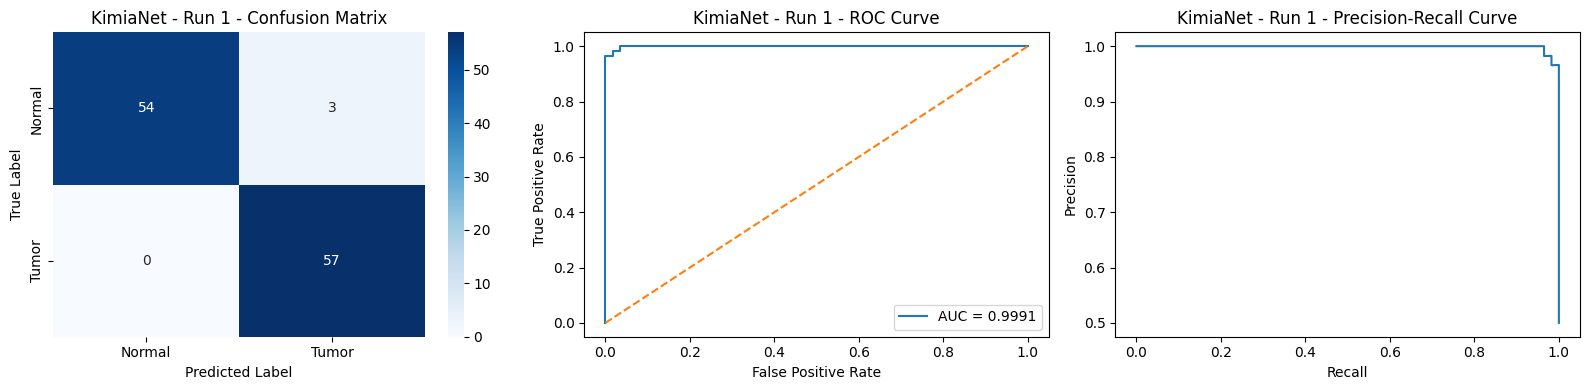


------------------------------------------------------------
KimiaNet | RUN 2/5
------------------------------------------------------------

[KimiaNet] Epoch 1/30
Train Loss : 0.2187
Val Loss   : 0.4213
Val Acc    : 0.9035
Val Spec   : 0.8772
Val Recall : 0.9298
Val F1     : 0.9060
Val AUC    : 0.9360
Best model saved based on Val AUC -> /content/best_model_kimianet_run2.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 2/30
Train Loss : 0.0740
Val Loss   : 0.4927
Val Acc    : 0.8684
Val Spec   : 0.8070
Val Recall : 0.9298
Val F1     : 0.8760
Val AUC    : 0.9400
Best model saved based on Val AUC -> /content/best_model_kimianet_run2.pth
No improvement in validation loss. Patience: 1/15

[KimiaNet] Epoch 3/30
Train Loss : 0.0328
Val Loss   : 0.5155
Val Acc    : 0.8772
Val Spec   : 0.8421
Val Recall : 0.9123
Val F1     : 0.8814
Val AUC    : 0.9400
No improvement in validation loss. Patience: 2/15

[KimiaNet] Epoch 4/30
Train Loss : 0.0182
Val Loss   : 0.5546
Val Acc    : 0

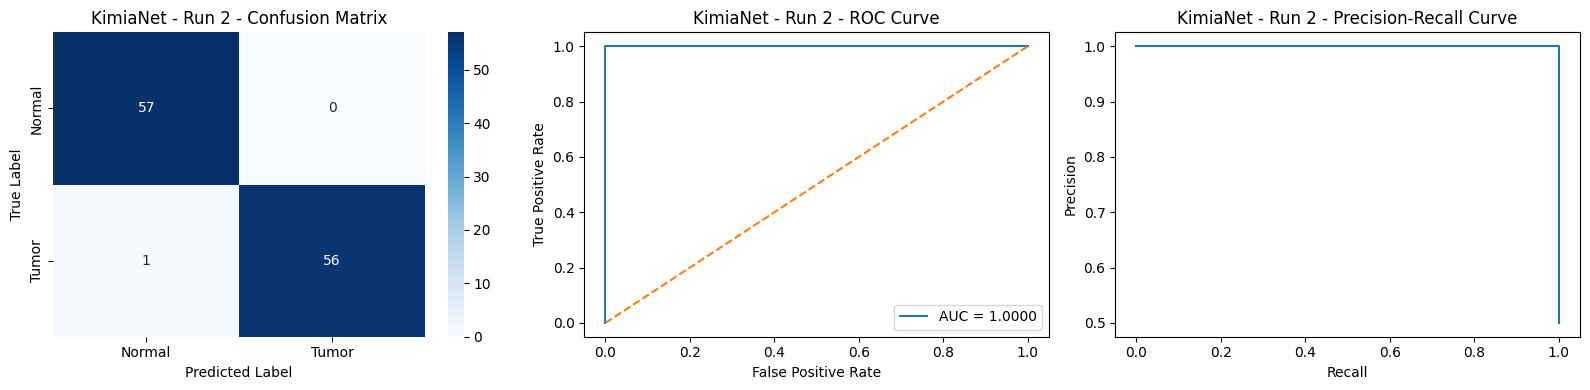


------------------------------------------------------------
KimiaNet | RUN 3/5
------------------------------------------------------------

[KimiaNet] Epoch 1/30
Train Loss : 0.1742
Val Loss   : 0.3918
Val Acc    : 0.8684
Val Spec   : 0.8070
Val Recall : 0.9298
Val F1     : 0.8760
Val AUC    : 0.9591
Best model saved based on Val AUC -> /content/best_model_kimianet_run3.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 2/30
Train Loss : 0.0748
Val Loss   : 0.4648
Val Acc    : 0.8684
Val Spec   : 0.8070
Val Recall : 0.9298
Val F1     : 0.8760
Val AUC    : 0.9409
No improvement in validation loss. Patience: 1/15

[KimiaNet] Epoch 3/30
Train Loss : 0.0404
Val Loss   : 0.4854
Val Acc    : 0.8772
Val Spec   : 0.8246
Val Recall : 0.9298
Val F1     : 0.8833
Val AUC    : 0.9532
No improvement in validation loss. Patience: 2/15

[KimiaNet] Epoch 4/30
Train Loss : 0.0215
Val Loss   : 0.4972
Val Acc    : 0.8860
Val Spec   : 0.8421
Val Recall : 0.9298
Val F1     : 0.8908
Val AUC  

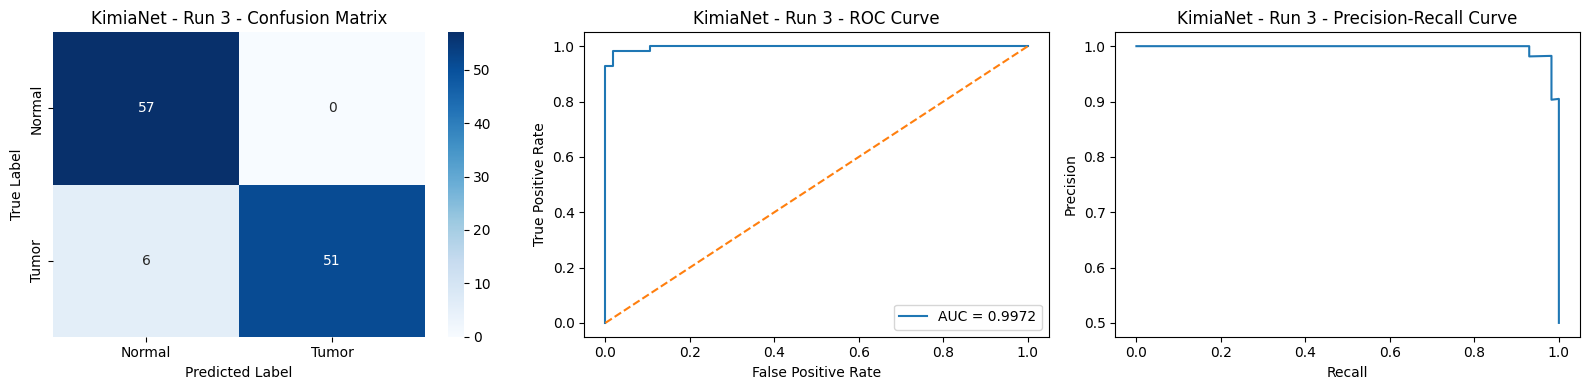


------------------------------------------------------------
KimiaNet | RUN 4/5
------------------------------------------------------------

[KimiaNet] Epoch 1/30
Train Loss : 0.1651
Val Loss   : 0.4037
Val Acc    : 0.8860
Val Spec   : 0.8596
Val Recall : 0.9123
Val F1     : 0.8889
Val AUC    : 0.9326
Best model saved based on Val AUC -> /content/best_model_kimianet_run4.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 2/30
Train Loss : 0.0579
Val Loss   : 0.5823
Val Acc    : 0.8772
Val Spec   : 0.8246
Val Recall : 0.9298
Val F1     : 0.8833
Val AUC    : 0.9243
No improvement in validation loss. Patience: 1/15

[KimiaNet] Epoch 3/30
Train Loss : 0.0616
Val Loss   : 0.4492
Val Acc    : 0.8684
Val Spec   : 0.7895
Val Recall : 0.9474
Val F1     : 0.8780
Val AUC    : 0.9588
Best model saved based on Val AUC -> /content/best_model_kimianet_run4.pth
No improvement in validation loss. Patience: 2/15

[KimiaNet] Epoch 4/30
Train Loss : 0.0241
Val Loss   : 0.5413
Val Acc    : 0

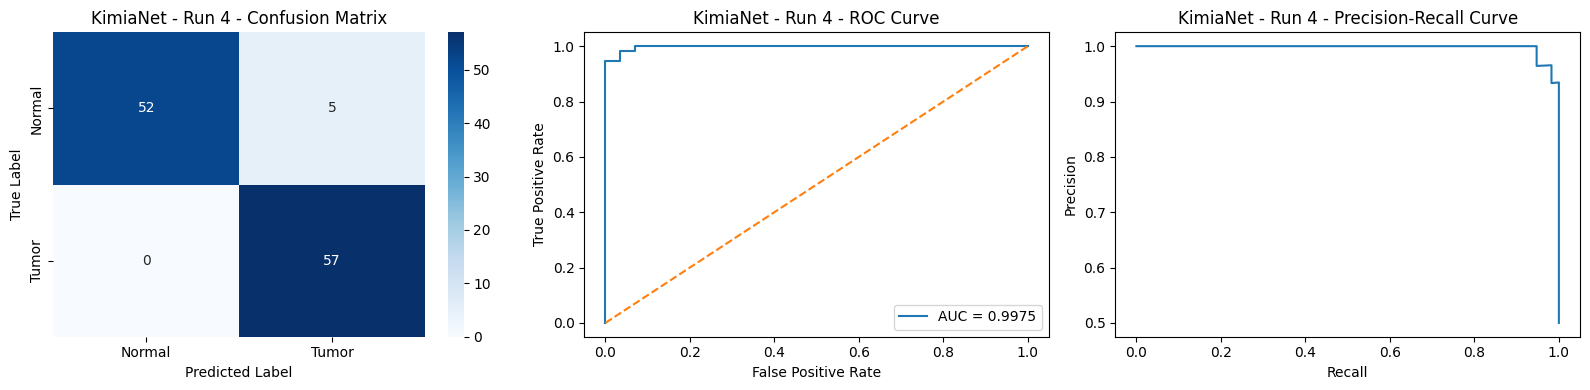


------------------------------------------------------------
KimiaNet | RUN 5/5
------------------------------------------------------------

[KimiaNet] Epoch 1/30
Train Loss : 0.1958
Val Loss   : 0.3787
Val Acc    : 0.8772
Val Spec   : 0.8947
Val Recall : 0.8596
Val F1     : 0.8750
Val AUC    : 0.9523
Best model saved based on Val AUC -> /content/best_model_kimianet_run5.pth
Validation loss improved. Patience reset.

[KimiaNet] Epoch 2/30
Train Loss : 0.0669
Val Loss   : 0.8964
Val Acc    : 0.7895
Val Spec   : 0.6316
Val Recall : 0.9474
Val F1     : 0.8182
Val AUC    : 0.9298
No improvement in validation loss. Patience: 1/15

[KimiaNet] Epoch 3/30
Train Loss : 0.0527
Val Loss   : 0.5364
Val Acc    : 0.8947
Val Spec   : 0.8596
Val Recall : 0.9298
Val F1     : 0.8983
Val AUC    : 0.9415
No improvement in validation loss. Patience: 2/15

[KimiaNet] Epoch 4/30
Train Loss : 0.0163
Val Loss   : 0.5109
Val Acc    : 0.9035
Val Spec   : 0.8947
Val Recall : 0.9123
Val F1     : 0.9043
Val AUC  

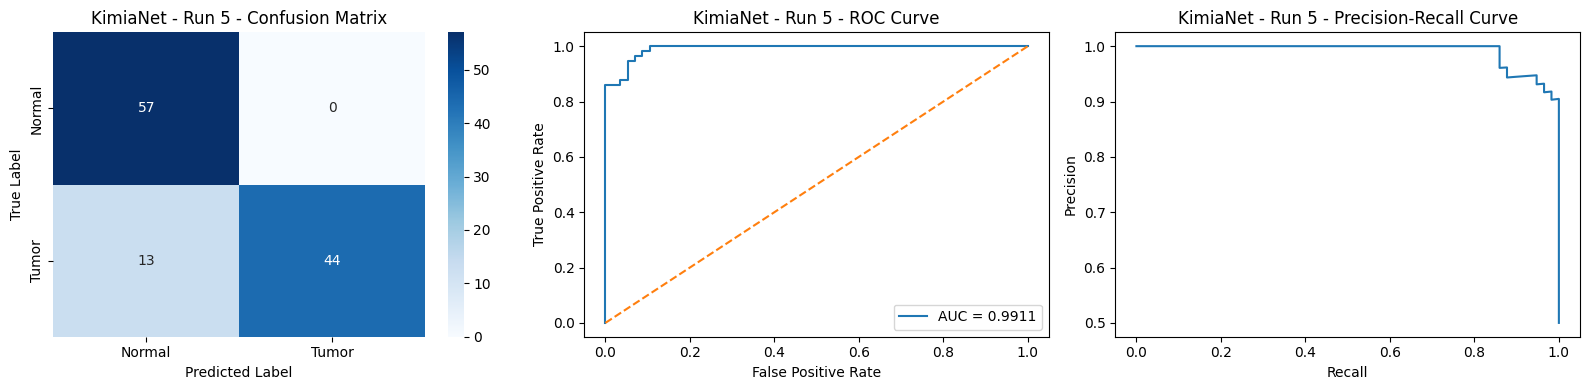

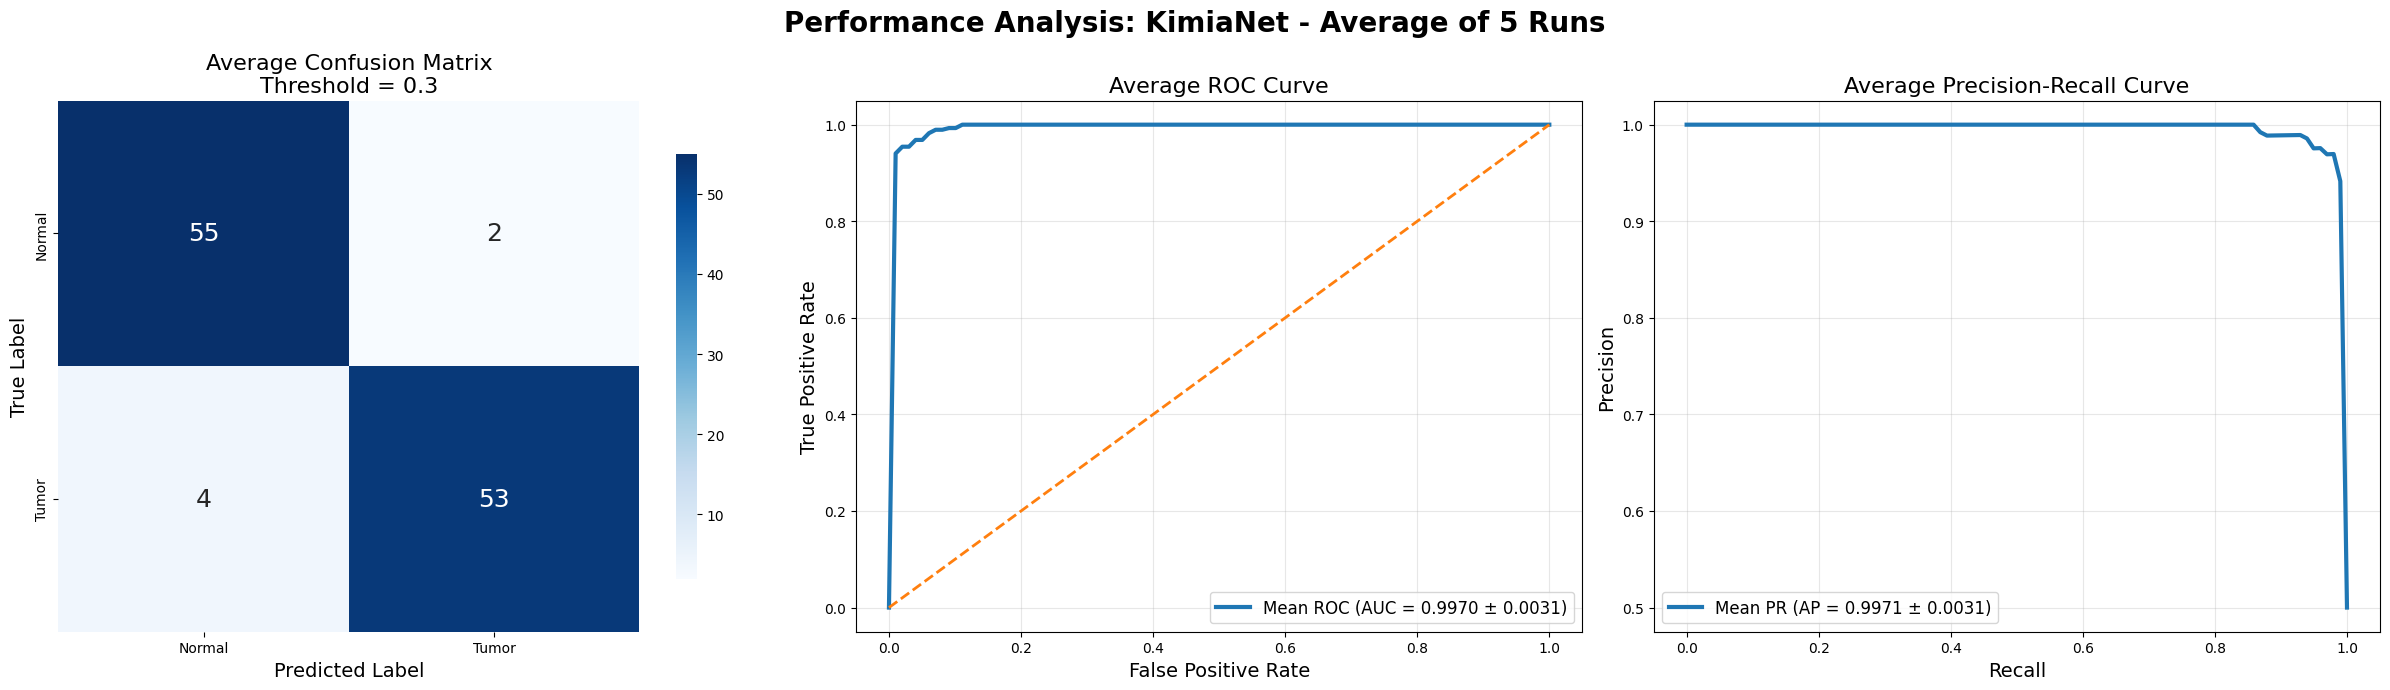


KimiaNet FINAL RESULTS (Mean ± Std)
  extractor         accuracy        precision      specificity  \
0  KimiaNet  0.9509 ± 0.0400  0.9739 ± 0.0374  0.9719 ± 0.0404   

            recall               f1              auc  
0  0.9298 ± 0.0985  0.9478 ± 0.0462  0.9970 ± 0.0035  


In [ ]:
kimianet_runs, kimianet_summary = run_single_extractor(
    "KimiaNet",
    EXTRACTORS["KimiaNet"]
)


Running AMIL with CTransPath
Train slides: 532
Val slides  : 114
Test slides : 114

------------------------------------------------------------
CTransPath | RUN 1/5
------------------------------------------------------------

[CTransPath] Epoch 1/30
Train Loss : 0.2168
Val Loss   : 0.1669
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9846
Best model saved based on Val AUC -> /content/best_model_ctranspath_run1.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 2/30
Train Loss : 0.0623
Val Loss   : 0.1666
Val Acc    : 0.9561
Val Spec   : 0.9298
Val Recall : 0.9825
Val F1     : 0.9573
Val AUC    : 0.9858
Best model saved based on Val AUC -> /content/best_model_ctranspath_run1.pth
No improvement in validation loss. Patience: 1/15

[CTransPath] Epoch 3/30
Train Loss : 0.0479
Val Loss   : 0.1894
Val Acc    : 0.9386
Val Spec   : 0.8947
Val Recall : 0.9825
Val F1     : 0.9412
Val AUC    : 0.9871
Best model saved based on Val A

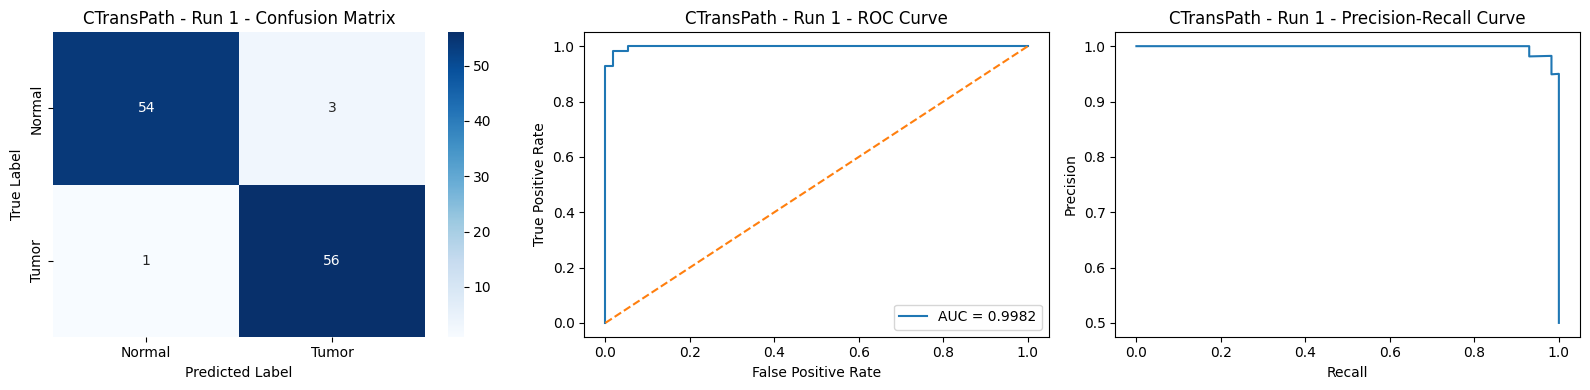


------------------------------------------------------------
CTransPath | RUN 2/5
------------------------------------------------------------

[CTransPath] Epoch 1/30
Train Loss : 0.2376
Val Loss   : 0.1873
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9797
Best model saved based on Val AUC -> /content/best_model_ctranspath_run2.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 2/30
Train Loss : 0.0690
Val Loss   : 0.2116
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9837
Best model saved based on Val AUC -> /content/best_model_ctranspath_run2.pth
No improvement in validation loss. Patience: 1/15

[CTransPath] Epoch 3/30
Train Loss : 0.0530
Val Loss   : 0.1708
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9865
Best model saved based on Val AUC -> /content/best_model_ctranspath_run2.pth
Validation loss improved. Patience res

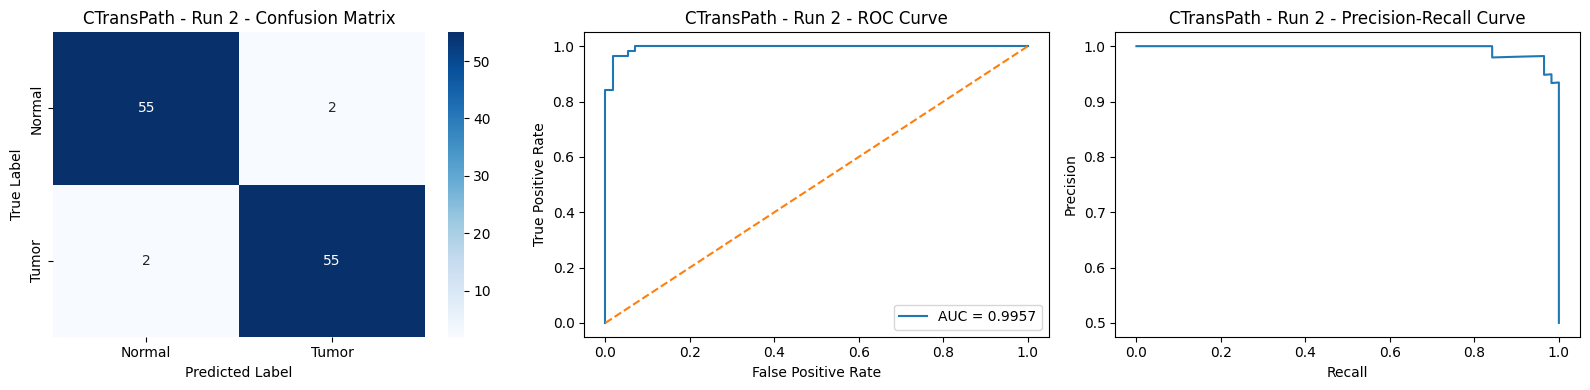


------------------------------------------------------------
CTransPath | RUN 3/5
------------------------------------------------------------

[CTransPath] Epoch 1/30
Train Loss : 0.2209
Val Loss   : 0.1880
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9806
Best model saved based on Val AUC -> /content/best_model_ctranspath_run3.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 2/30
Train Loss : 0.0665
Val Loss   : 0.1737
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9849
Best model saved based on Val AUC -> /content/best_model_ctranspath_run3.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 3/30
Train Loss : 0.0488
Val Loss   : 0.2317
Val Acc    : 0.9211
Val Spec   : 0.8596
Val Recall : 0.9825
Val F1     : 0.9256
Val AUC    : 0.9837
No improvement in validation loss. Patience: 1/15

[CTransPath] Epoch 4/30
Train Loss : 0.0413
Val Loss   : 0.2448
Val Acc 

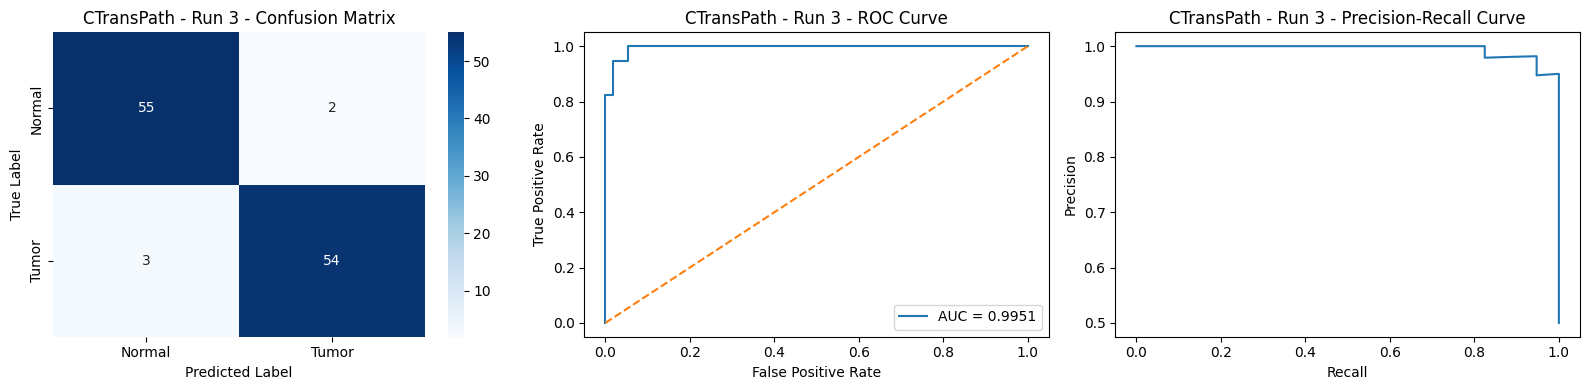


------------------------------------------------------------
CTransPath | RUN 4/5
------------------------------------------------------------

[CTransPath] Epoch 1/30
Train Loss : 0.2287
Val Loss   : 0.1804
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9806
Best model saved based on Val AUC -> /content/best_model_ctranspath_run4.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 2/30
Train Loss : 0.0687
Val Loss   : 0.1599
Val Acc    : 0.9386
Val Spec   : 0.9298
Val Recall : 0.9474
Val F1     : 0.9391
Val AUC    : 0.9868
Best model saved based on Val AUC -> /content/best_model_ctranspath_run4.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 3/30
Train Loss : 0.0549
Val Loss   : 0.1505
Val Acc    : 0.9474
Val Spec   : 0.9474
Val Recall : 0.9474
Val F1     : 0.9474
Val AUC    : 0.9883
Best model saved based on Val AUC -> /content/best_model_ctranspath_run4.pth
Validation loss improved. Patience reset.

[CT

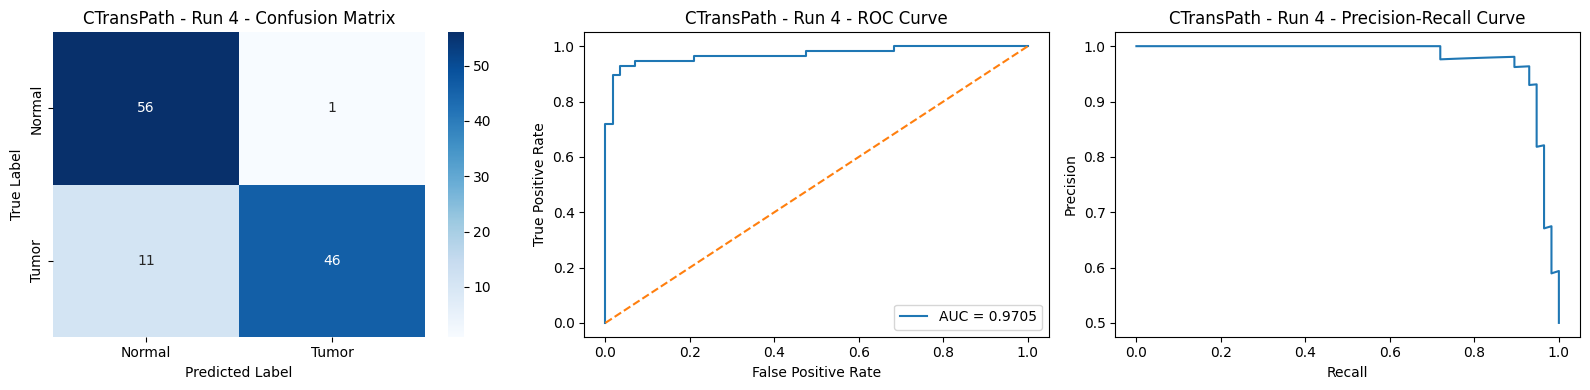


------------------------------------------------------------
CTransPath | RUN 5/5
------------------------------------------------------------

[CTransPath] Epoch 1/30
Train Loss : 0.2294
Val Loss   : 0.2202
Val Acc    : 0.9123
Val Spec   : 0.8421
Val Recall : 0.9825
Val F1     : 0.9180
Val AUC    : 0.9785
Best model saved based on Val AUC -> /content/best_model_ctranspath_run5.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 2/30
Train Loss : 0.0705
Val Loss   : 0.1801
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9855
Best model saved based on Val AUC -> /content/best_model_ctranspath_run5.pth
Validation loss improved. Patience reset.

[CTransPath] Epoch 3/30
Train Loss : 0.0497
Val Loss   : 0.1862
Val Acc    : 0.9298
Val Spec   : 0.8772
Val Recall : 0.9825
Val F1     : 0.9333
Val AUC    : 0.9858
Best model saved based on Val AUC -> /content/best_model_ctranspath_run5.pth
No improvement in validation loss. Patience: 1

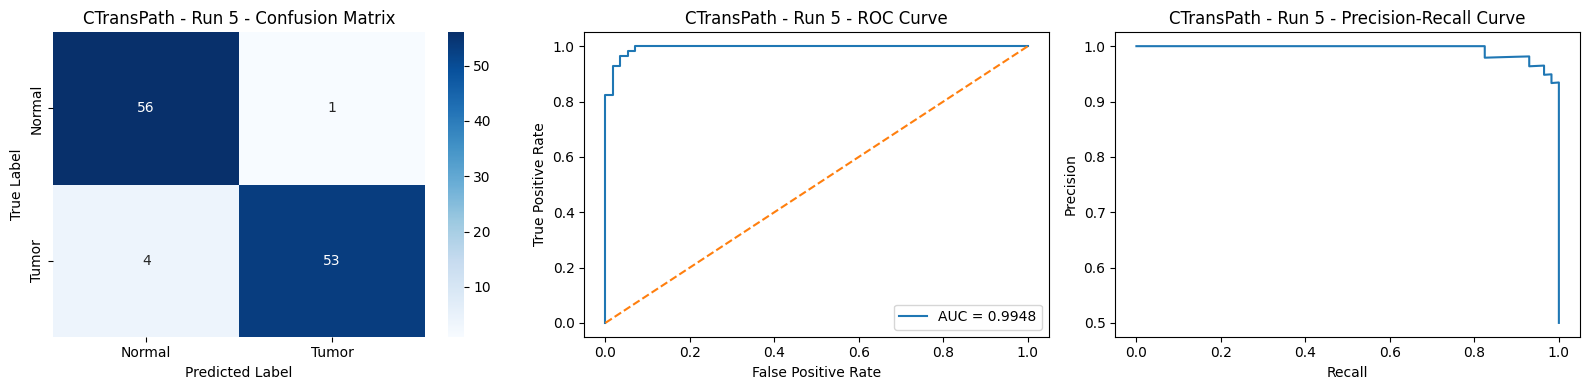

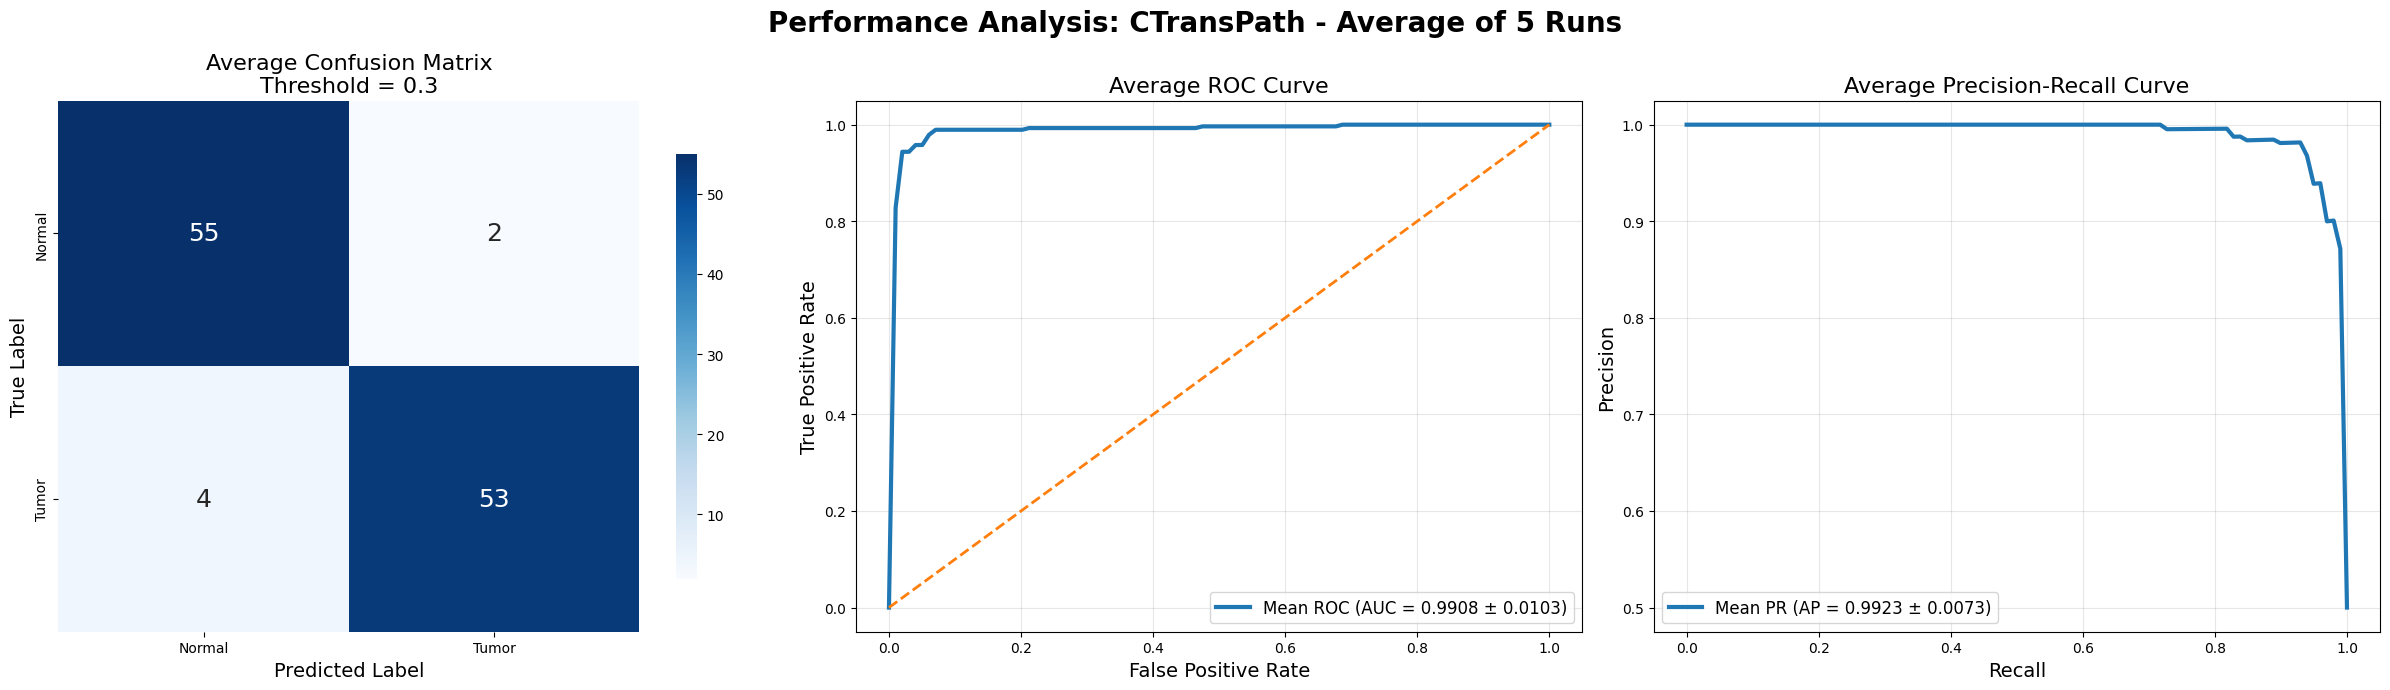


CTransPath FINAL RESULTS (Mean ± Std)
    extractor         accuracy        precision      specificity  \
0  CTransPath  0.9474 ± 0.0297  0.9677 ± 0.0130  0.9684 ± 0.0147   

            recall               f1              auc  
0  0.9263 ± 0.0695  0.9452 ± 0.0342  0.9908 ± 0.0115  


In [ ]:
ctranspath_runs, ctranspath_summary = run_single_extractor(
    "CTransPath",
    EXTRACTORS["CTransPath"]
)


Running AMIL with MobileNet
Train slides: 532
Val slides  : 114
Test slides : 114

------------------------------------------------------------
MobileNet | RUN 1/5
------------------------------------------------------------

[MobileNet] Epoch 1/30
Train Loss : 0.2603
Val Loss   : 0.2208
Val Acc    : 0.9211
Val Spec   : 0.9298
Val Recall : 0.9123
Val F1     : 0.9204
Val AUC    : 0.9797
Best model saved based on Val AUC -> /content/best_model_mobilenet_run1.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 2/30
Train Loss : 0.1288
Val Loss   : 0.1938
Val Acc    : 0.9035
Val Spec   : 0.8421
Val Recall : 0.9649
Val F1     : 0.9091
Val AUC    : 0.9797
Validation loss improved. Patience reset.

[MobileNet] Epoch 3/30
Train Loss : 0.0988
Val Loss   : 0.2212
Val Acc    : 0.9035
Val Spec   : 0.8421
Val Recall : 0.9649
Val F1     : 0.9091
Val AUC    : 0.9781
No improvement in validation loss. Patience: 1/15

[MobileNet] Epoch 4/30
Train Loss : 0.0810
Val Loss   : 0.2115
Val Acc 

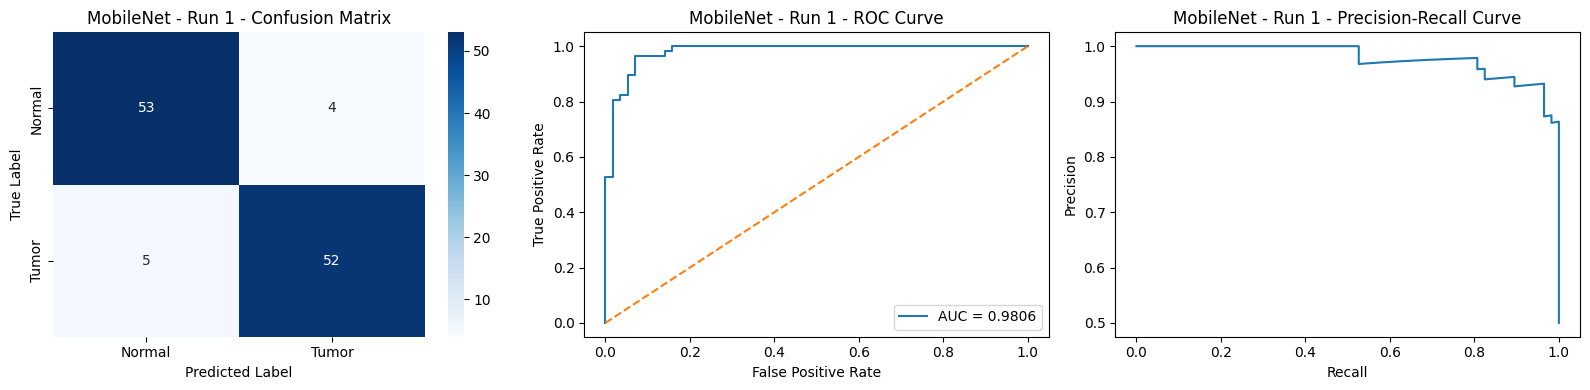


------------------------------------------------------------
MobileNet | RUN 2/5
------------------------------------------------------------

[MobileNet] Epoch 1/30
Train Loss : 0.2390
Val Loss   : 0.1935
Val Acc    : 0.9035
Val Spec   : 0.8246
Val Recall : 0.9825
Val F1     : 0.9106
Val AUC    : 0.9825
Best model saved based on Val AUC -> /content/best_model_mobilenet_run2.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 2/30
Train Loss : 0.1391
Val Loss   : 0.1780
Val Acc    : 0.9123
Val Spec   : 0.8772
Val Recall : 0.9474
Val F1     : 0.9153
Val AUC    : 0.9812
Validation loss improved. Patience reset.

[MobileNet] Epoch 3/30
Train Loss : 0.0808
Val Loss   : 0.1836
Val Acc    : 0.9211
Val Spec   : 0.8947
Val Recall : 0.9474
Val F1     : 0.9231
Val AUC    : 0.9840
Best model saved based on Val AUC -> /content/best_model_mobilenet_run2.pth
No improvement in validation loss. Patience: 1/15

[MobileNet] Epoch 4/30
Train Loss : 0.1109
Val Loss   : 0.2224
Val Acc    : 0.

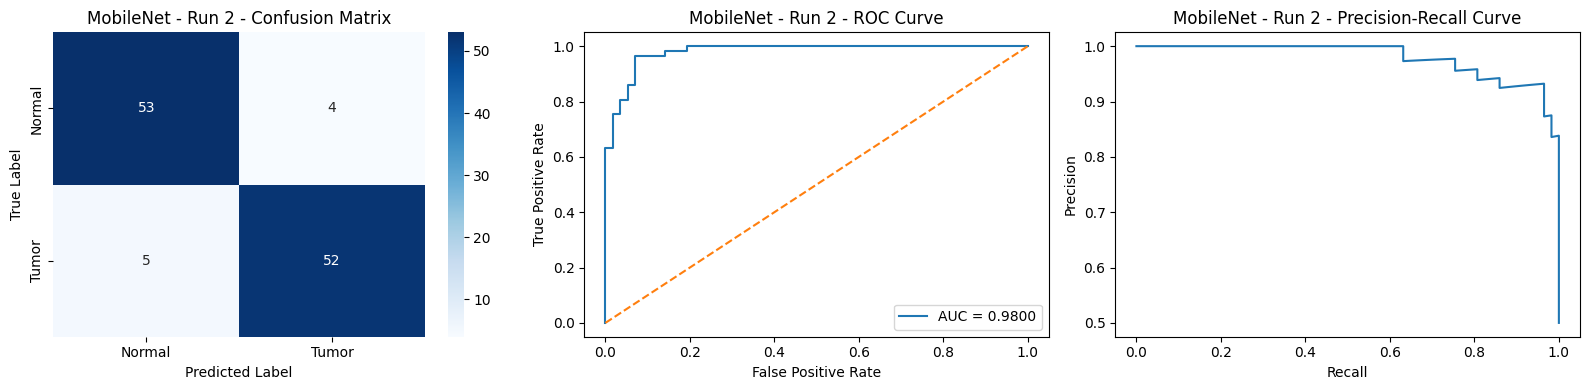


------------------------------------------------------------
MobileNet | RUN 3/5
------------------------------------------------------------

[MobileNet] Epoch 1/30
Train Loss : 0.2550
Val Loss   : 0.2219
Val Acc    : 0.9123
Val Spec   : 0.8947
Val Recall : 0.9298
Val F1     : 0.9138
Val AUC    : 0.9754
Best model saved based on Val AUC -> /content/best_model_mobilenet_run3.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 2/30
Train Loss : 0.1406
Val Loss   : 0.2209
Val Acc    : 0.9035
Val Spec   : 0.8246
Val Recall : 0.9825
Val F1     : 0.9106
Val AUC    : 0.9821
Best model saved based on Val AUC -> /content/best_model_mobilenet_run3.pth
No improvement in validation loss. Patience: 1/15

[MobileNet] Epoch 3/30
Train Loss : 0.0991
Val Loss   : 0.1937
Val Acc    : 0.9123
Val Spec   : 0.8947
Val Recall : 0.9298
Val F1     : 0.9138
Val AUC    : 0.9815
Validation loss improved. Patience reset.

[MobileNet] Epoch 4/30
Train Loss : 0.0794
Val Loss   : 0.2281
Val Acc    : 0.

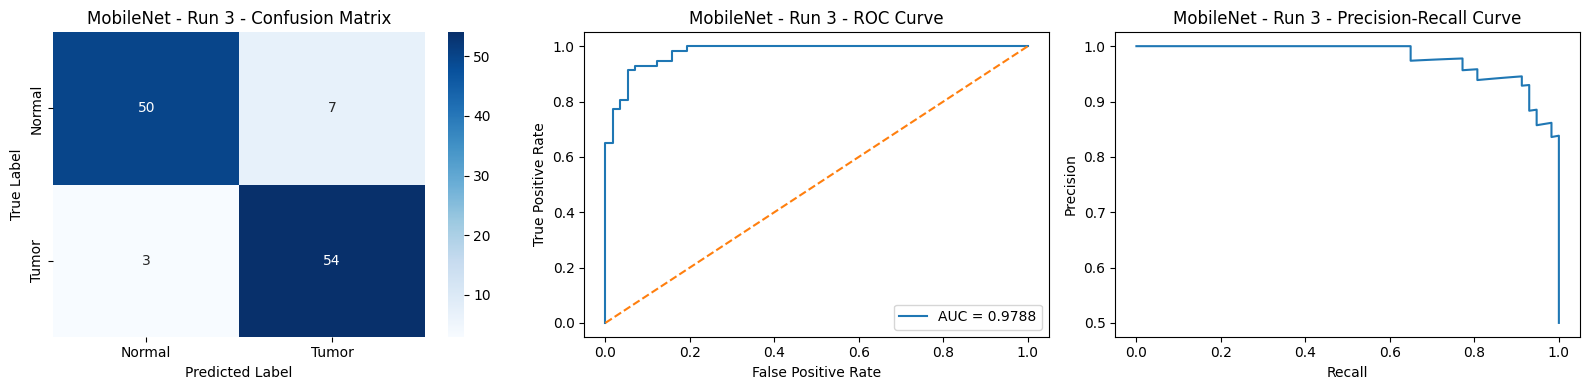


------------------------------------------------------------
MobileNet | RUN 4/5
------------------------------------------------------------

[MobileNet] Epoch 1/30
Train Loss : 0.2562
Val Loss   : 0.2094
Val Acc    : 0.8947
Val Spec   : 0.8070
Val Recall : 0.9825
Val F1     : 0.9032
Val AUC    : 0.9781
Best model saved based on Val AUC -> /content/best_model_mobilenet_run4.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 2/30
Train Loss : 0.1466
Val Loss   : 0.2350
Val Acc    : 0.8860
Val Spec   : 0.7895
Val Recall : 0.9825
Val F1     : 0.8960
Val AUC    : 0.9812
Best model saved based on Val AUC -> /content/best_model_mobilenet_run4.pth
No improvement in validation loss. Patience: 1/15

[MobileNet] Epoch 3/30
Train Loss : 0.0924
Val Loss   : 0.2249
Val Acc    : 0.9123
Val Spec   : 0.8947
Val Recall : 0.9298
Val F1     : 0.9138
Val AUC    : 0.9760
No improvement in validation loss. Patience: 2/15

[MobileNet] Epoch 4/30
Train Loss : 0.0803
Val Loss   : 0.2747
Val Acc

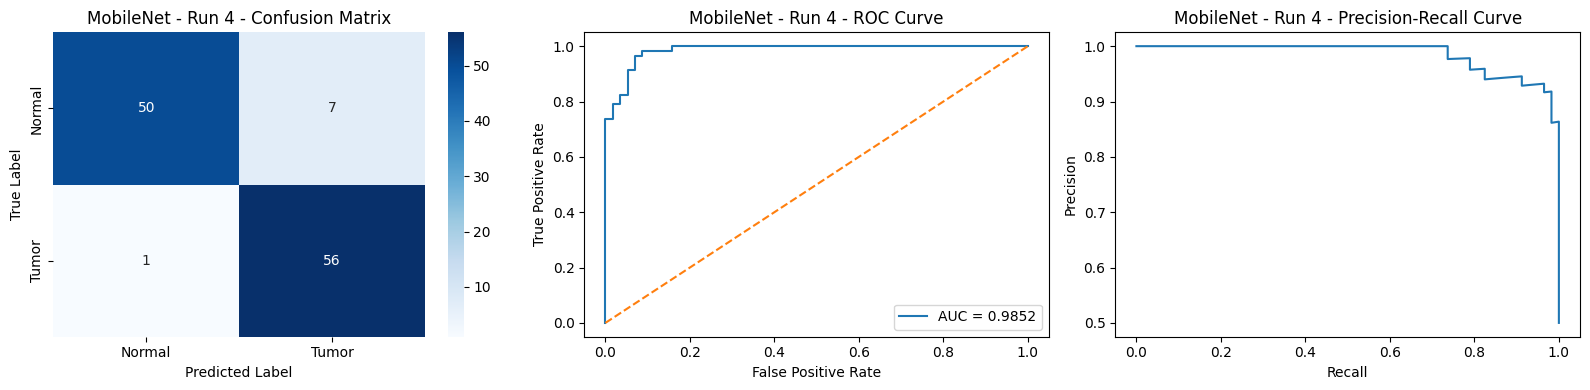


------------------------------------------------------------
MobileNet | RUN 5/5
------------------------------------------------------------

[MobileNet] Epoch 1/30
Train Loss : 0.2459
Val Loss   : 0.2626
Val Acc    : 0.8772
Val Spec   : 0.7544
Val Recall : 1.0000
Val F1     : 0.8906
Val AUC    : 0.9815
Best model saved based on Val AUC -> /content/best_model_mobilenet_run5.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 2/30
Train Loss : 0.1316
Val Loss   : 0.1983
Val Acc    : 0.9123
Val Spec   : 0.8421
Val Recall : 0.9825
Val F1     : 0.9180
Val AUC    : 0.9818
Best model saved based on Val AUC -> /content/best_model_mobilenet_run5.pth
Validation loss improved. Patience reset.

[MobileNet] Epoch 3/30
Train Loss : 0.0835
Val Loss   : 0.2230
Val Acc    : 0.8860
Val Spec   : 0.7895
Val Recall : 0.9825
Val F1     : 0.8960
Val AUC    : 0.9840
Best model saved based on Val AUC -> /content/best_model_mobilenet_run5.pth
No improvement in validation loss. Patience: 1/15

[M

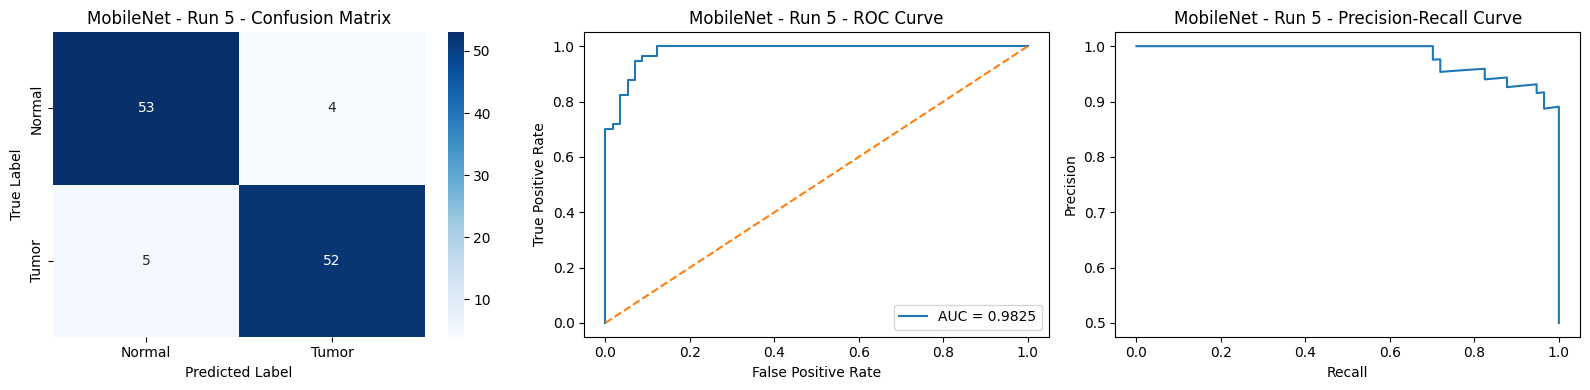

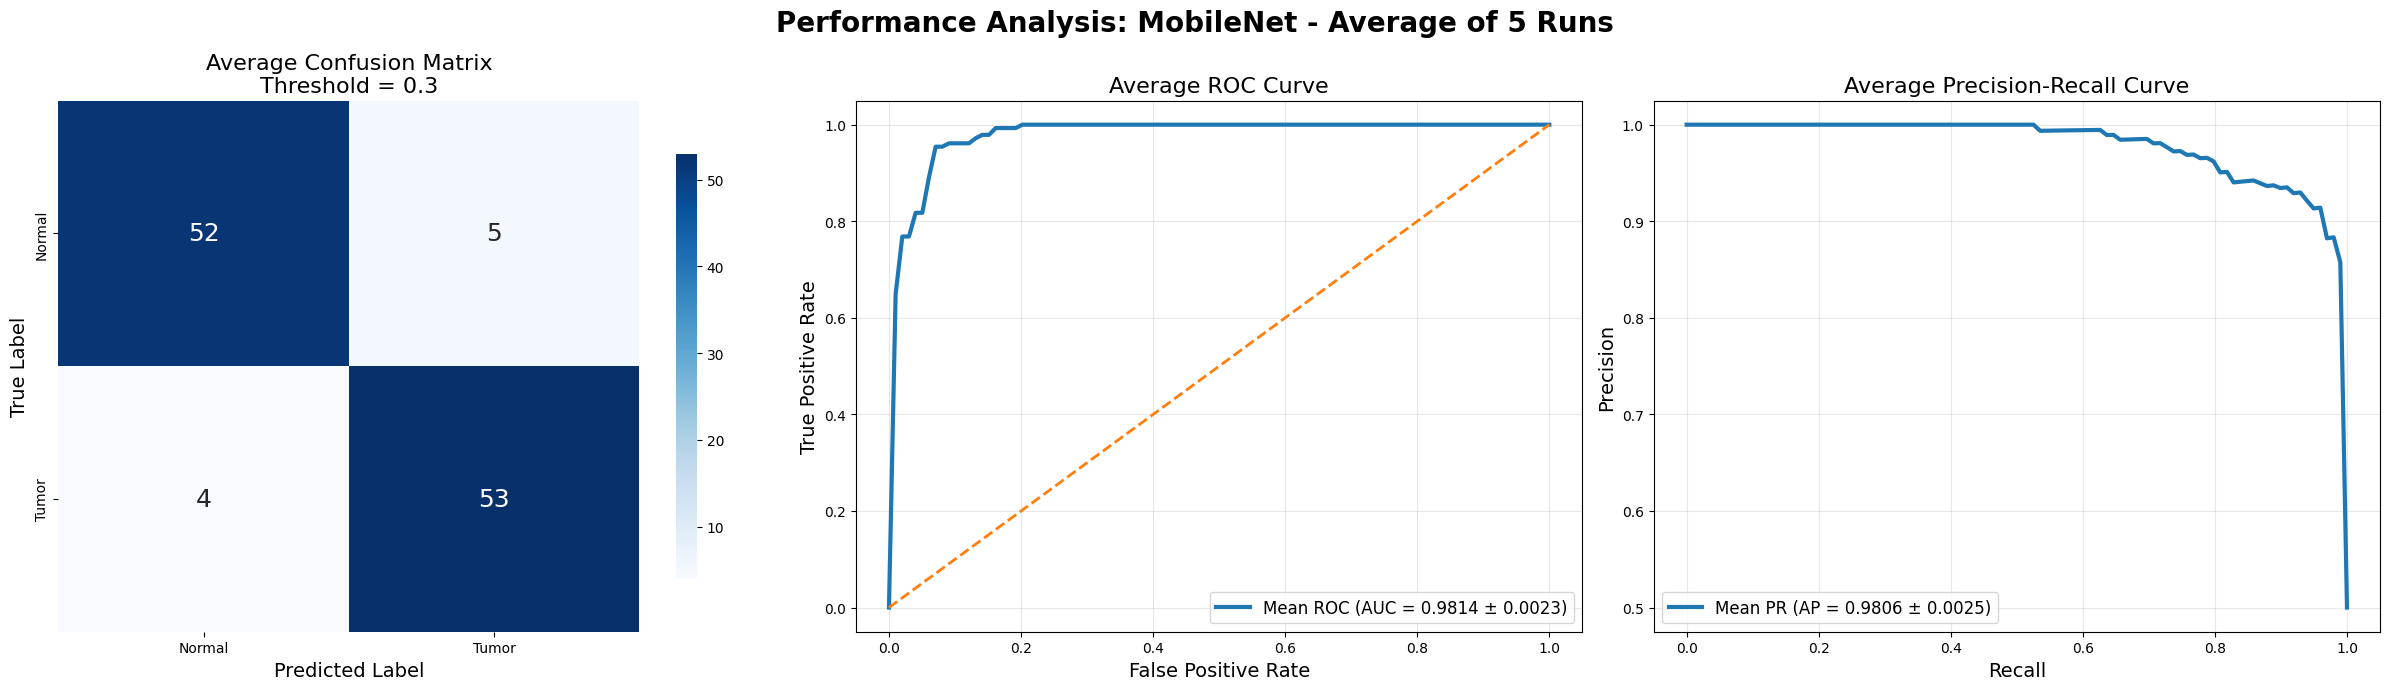


MobileNet FINAL RESULTS (Mean ± Std)
   extractor         accuracy        precision      specificity  \
0  MobileNet  0.9211 ± 0.0062  0.9120 ± 0.0228  0.9088 ± 0.0288   

            recall               f1              auc  
0  0.9333 ± 0.0314  0.9219 ± 0.0067  0.9814 ± 0.0025  


In [ ]:
mobilenet_runs, mobilenet_summary = run_single_extractor(
    "MobileNet",
    EXTRACTORS["MobileNet"]
)

In [ ]:
summary_df = pd.concat(
    [kimianet_summary, mobilenet_summary, ctranspath_summary],
    ignore_index=True
)

print("\nFINAL COMPARISON - MEAN ± STD")
print(summary_df)


FINAL COMPARISON - MEAN ± STD
    extractor         accuracy        precision      specificity  \
0    KimiaNet  0.9509 ± 0.0400  0.9739 ± 0.0374  0.9719 ± 0.0404   
1   MobileNet  0.9211 ± 0.0062  0.9120 ± 0.0228  0.9088 ± 0.0288   
2  CTransPath  0.9474 ± 0.0297  0.9677 ± 0.0130  0.9684 ± 0.0147   

            recall               f1              auc  
0  0.9298 ± 0.0985  0.9478 ± 0.0462  0.9970 ± 0.0035  
1  0.9333 ± 0.0314  0.9219 ± 0.0067  0.9814 ± 0.0025  
2  0.9263 ± 0.0695  0.9452 ± 0.0342  0.9908 ± 0.0115  


In [ ]:
# =========================================================
# EXTERNAL TEST HELPER
# =========================================================

def external_test_single_extractor(
    extractor_name,
    external_test_dir,
    input_dim,
    model_path,
    threshold=0.3
):
    print("\n" + "=" * 70)
    print(f"External Test - {extractor_name}")
    print("=" * 70)

    external_dataset = H5SlideDataset(
        external_test_dir,
        max_patches=MAX_PATCHES
    )

    external_loader = DataLoader(
        external_dataset,
        batch_size=1,
        shuffle=False,
        collate_fn=collate_bags
    )

    print("External test slides:", len(external_dataset))
    all_external_y_true = []
    all_external_y_probs = []

    model = AMIL(
        input_dim=input_dim,
        gate=True,
        size_arg="small",
        dropout=True
    ).to(device)

    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    model.eval()

    criterion = nn.BCEWithLogitsLoss()

    external_metrics = evaluate(
        model,
        external_loader,
        criterion,
        device,
        threshold=threshold
    )
    all_external_y_true.append(external_metrics["y_true"])
    all_external_y_probs.append(external_metrics["y_prob"])

    plot_test_results(
        external_metrics,
        f"{extractor_name} - External Test"
    )
    plot_average_5_runs(
    extractor=f"{extractor_name} - External",
    all_runs_y_true=all_external_y_true,
    all_runs_y_probs=all_external_y_probs,
    threshold=threshold )

    return {
        "extractor": extractor_name,
        "accuracy": external_metrics["accuracy"],
        "precision": external_metrics["precision"],
        "specificity": external_metrics["specificity"],
        "recall": external_metrics["recall"],
        "f1": external_metrics["f1"],
        "auc": external_metrics["auc"]
    }


External Test - KimiaNet External Run 1
External test slides: 804

========== KimiaNet External Run 1 - External Test TEST RESULTS ==========
Test Loss   : 0.4848
Test Acc    : 0.9154
Test Prec   : 0.9665
Test Recall : 0.8607
Test Spec   : 0.9701
Test F1     : 0.9105
Test AUC    : 0.9752

Results Table:
        Metric     Value
0         Loss  0.484790
1     Accuracy  0.915423
2  specificity  0.966480
3    Precision  0.970149
4       Recall  0.860697
5     F1-score  0.910526
6          AUC  0.975248


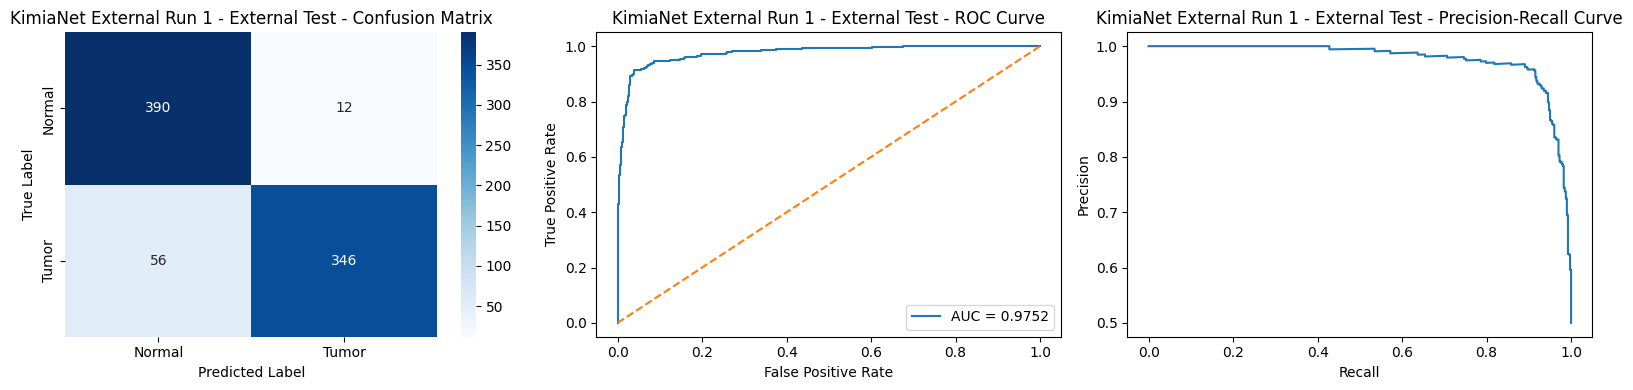

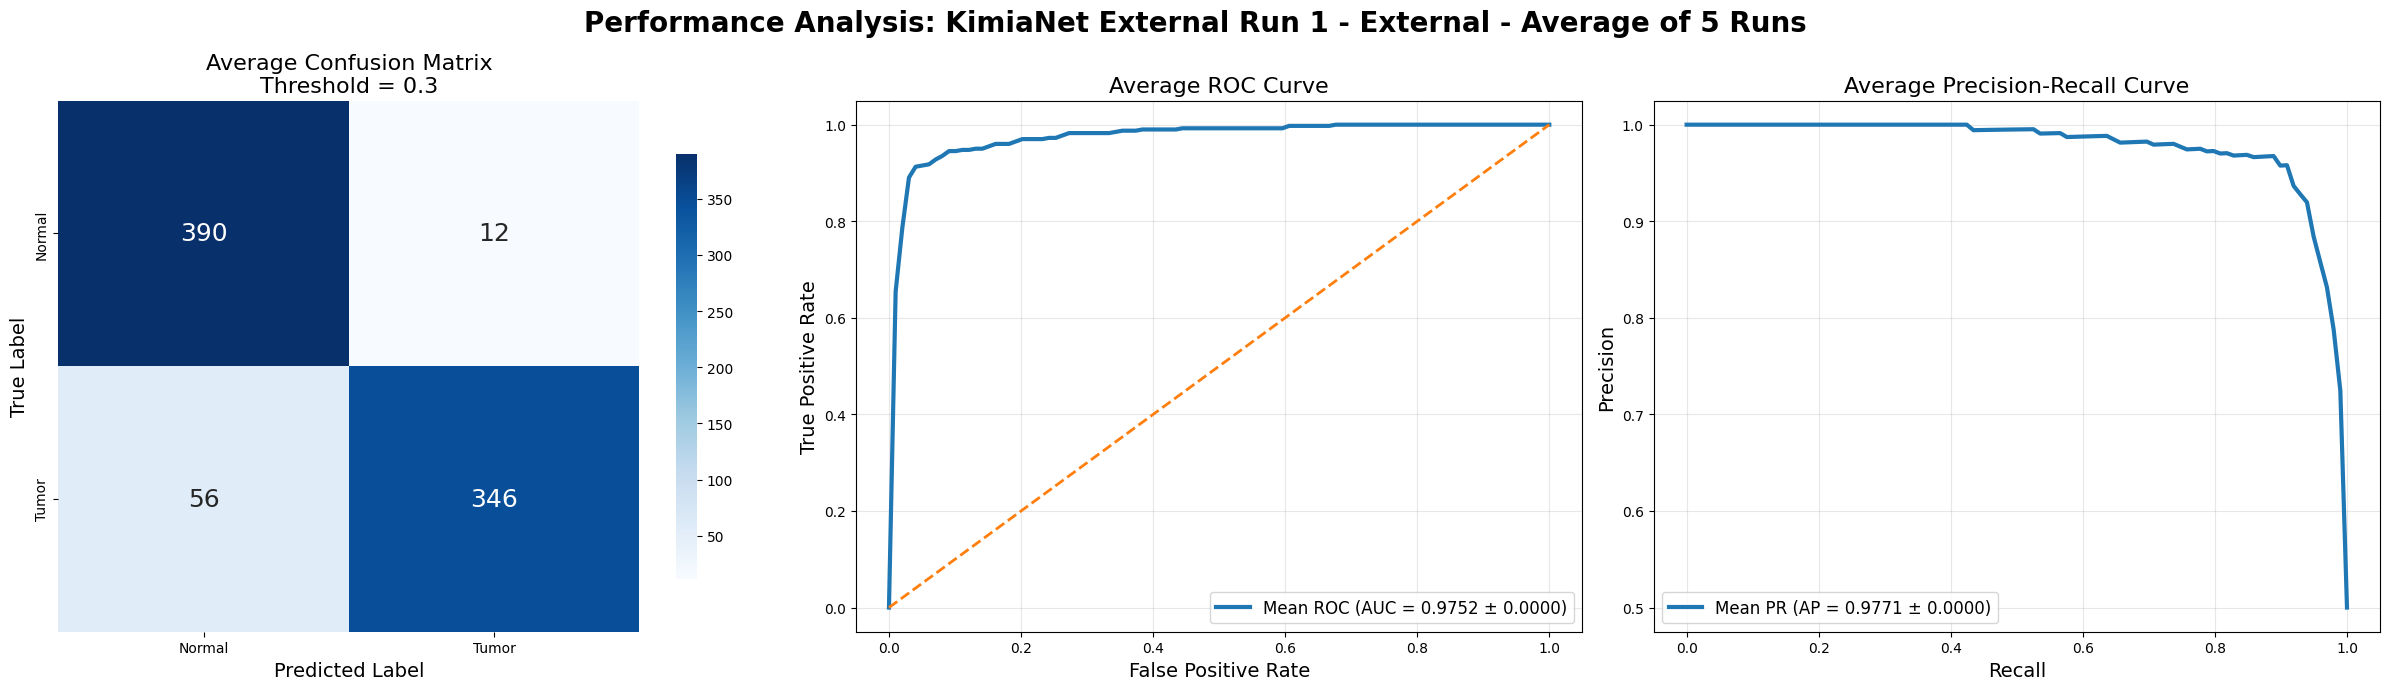


External Test - KimiaNet External Run 2
External test slides: 804

========== KimiaNet External Run 2 - External Test TEST RESULTS ==========
Test Loss   : 0.5319
Test Acc    : 0.8893
Test Prec   : 0.9757
Test Recall : 0.7985
Test Spec   : 0.9801
Test F1     : 0.8782
Test AUC    : 0.9768

Results Table:
        Metric     Value
0         Loss  0.531921
1     Accuracy  0.889303
2  specificity  0.975684
3    Precision  0.980100
4       Recall  0.798507
5     F1-score  0.878249
6          AUC  0.976826


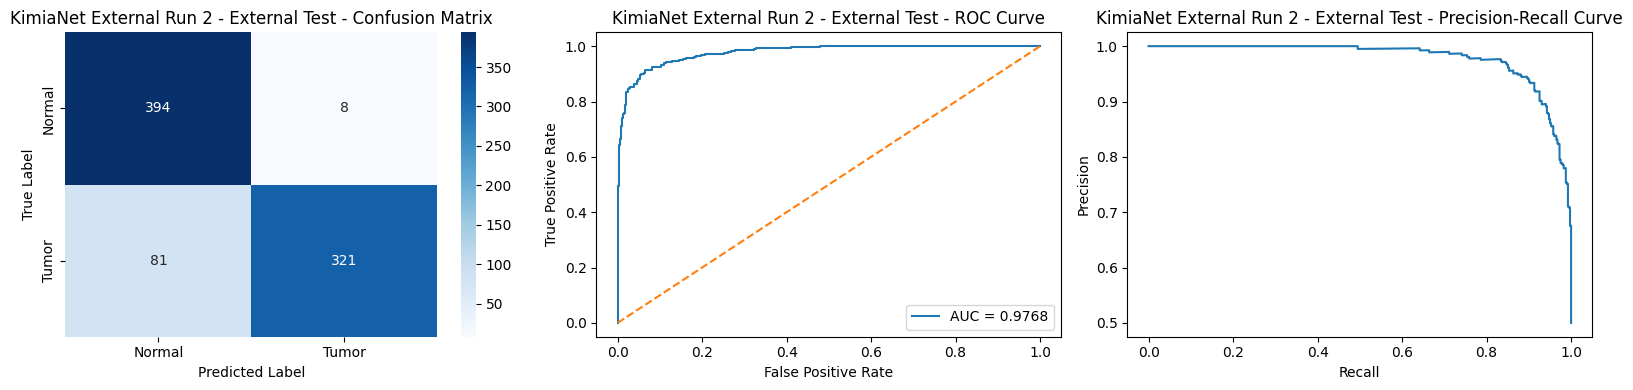

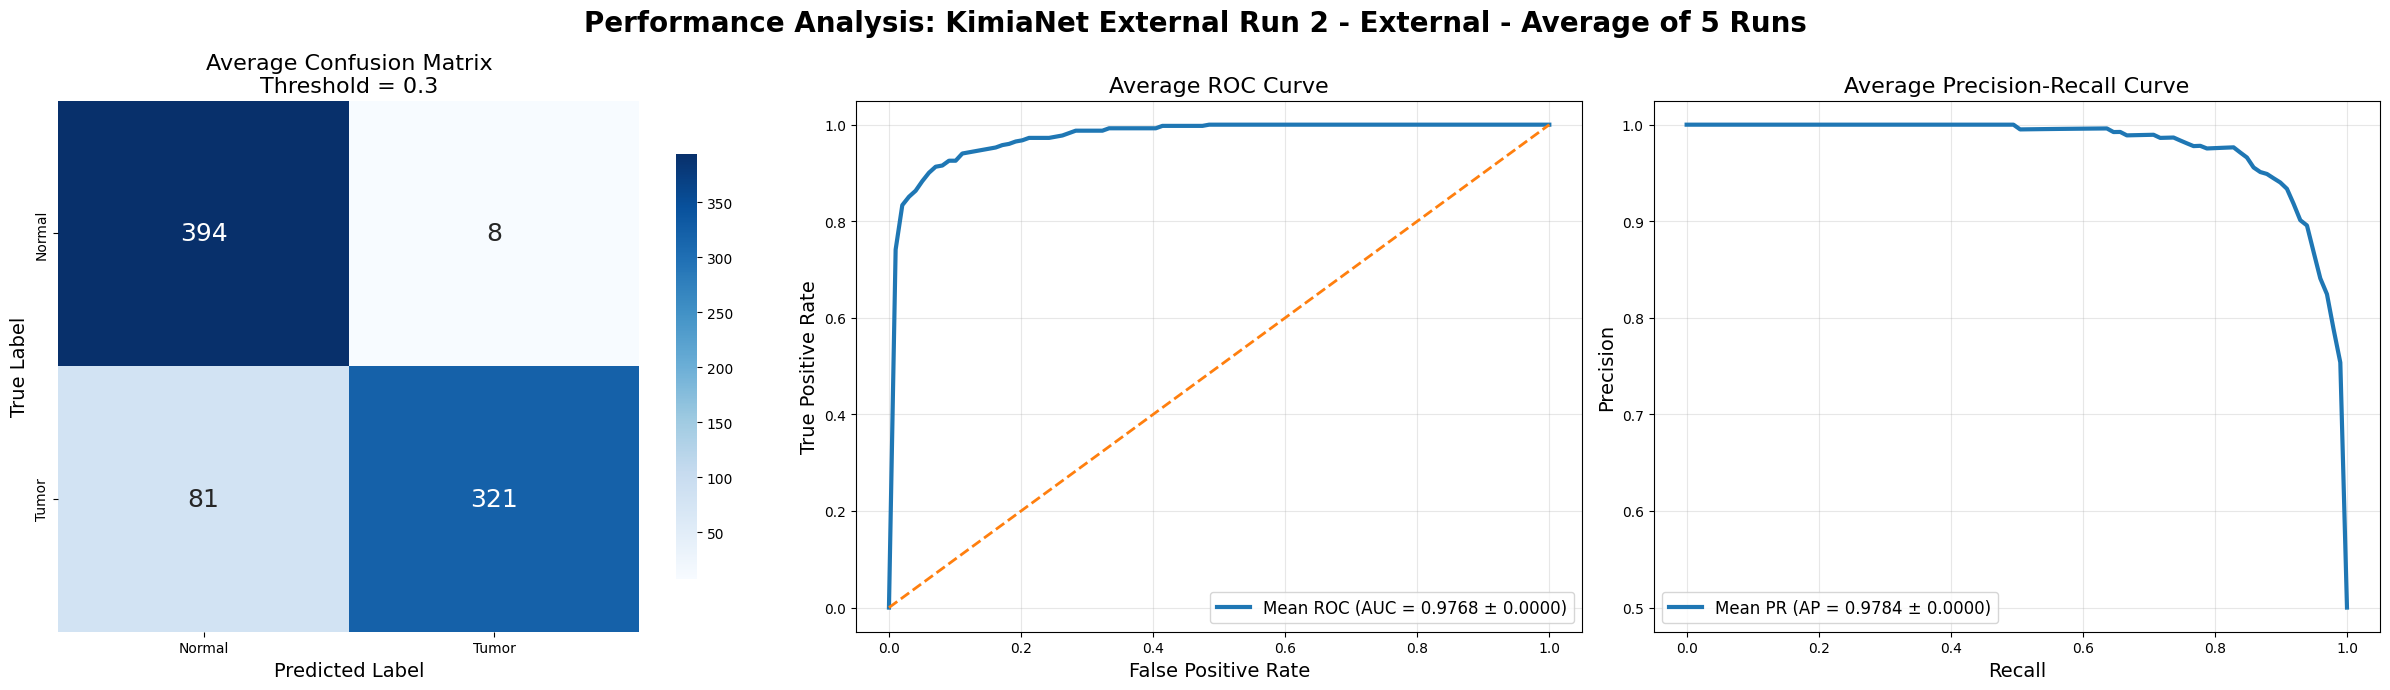


External Test - KimiaNet External Run 3
External test slides: 804

========== KimiaNet External Run 3 - External Test TEST RESULTS ==========
Test Loss   : 0.5164
Test Acc    : 0.8918
Test Prec   : 0.9787
Test Recall : 0.8010
Test Spec   : 0.9826
Test F1     : 0.8810
Test AUC    : 0.9803

Results Table:
        Metric     Value
0         Loss  0.516378
1     Accuracy  0.891791
2  specificity  0.978723
3    Precision  0.982587
4       Recall  0.800995
5     F1-score  0.880985
6          AUC  0.980279


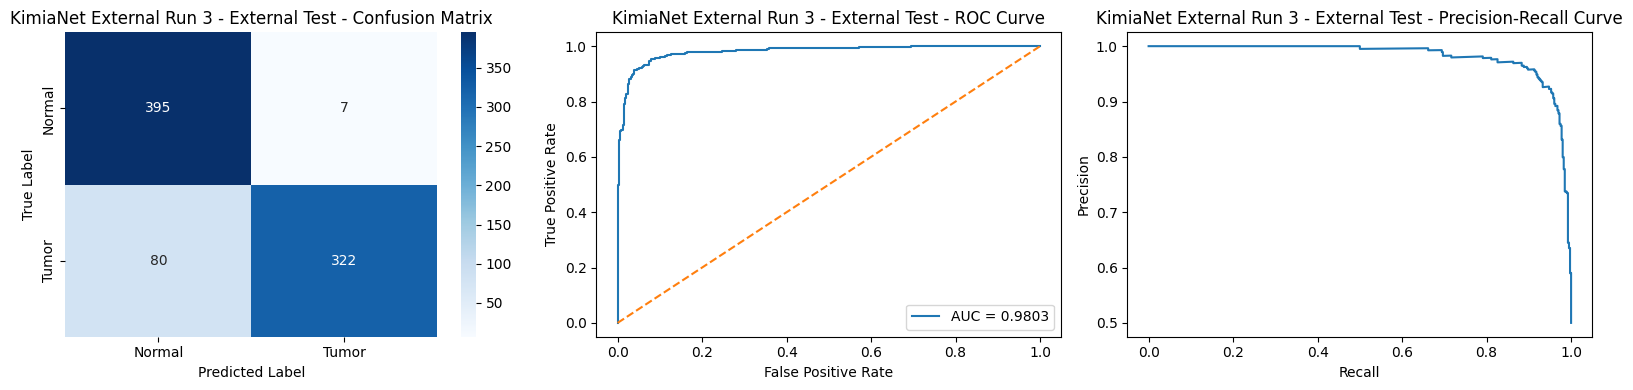

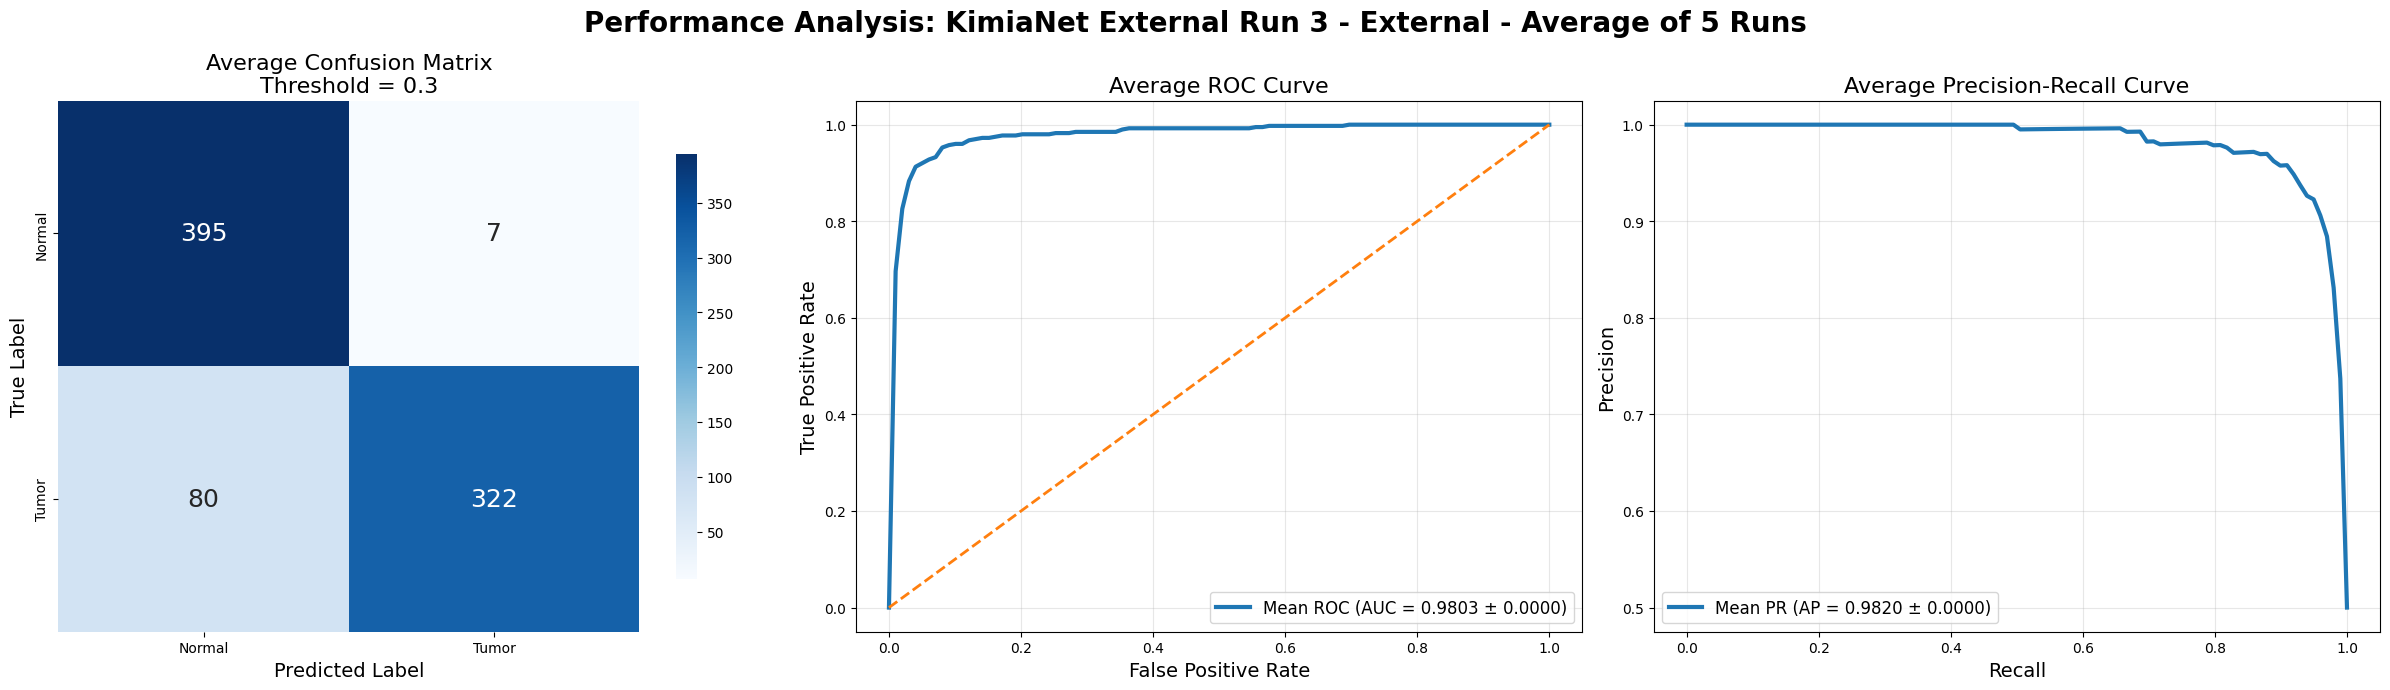


External Test - KimiaNet External Run 4
External test slides: 804

========== KimiaNet External Run 4 - External Test TEST RESULTS ==========
Test Loss   : 0.2449
Test Acc    : 0.9279
Test Prec   : 0.9365
Test Recall : 0.9179
Test Spec   : 0.9378
Test F1     : 0.9271
Test AUC    : 0.9765

Results Table:
        Metric     Value
0         Loss  0.244873
1     Accuracy  0.927861
2  specificity  0.936548
3    Precision  0.937811
4       Recall  0.917910
5     F1-score  0.927136
6          AUC  0.976504


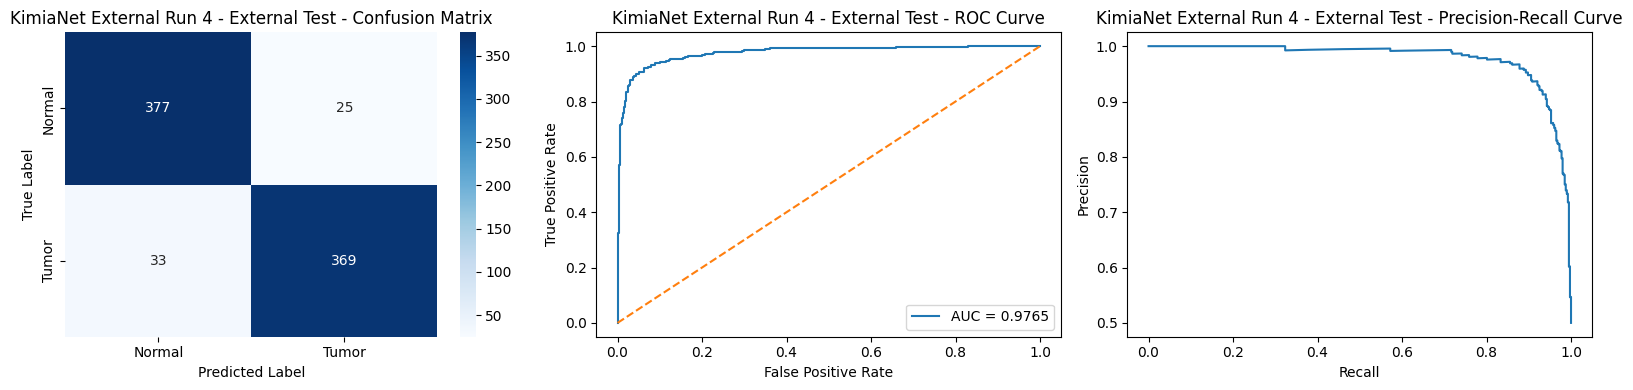

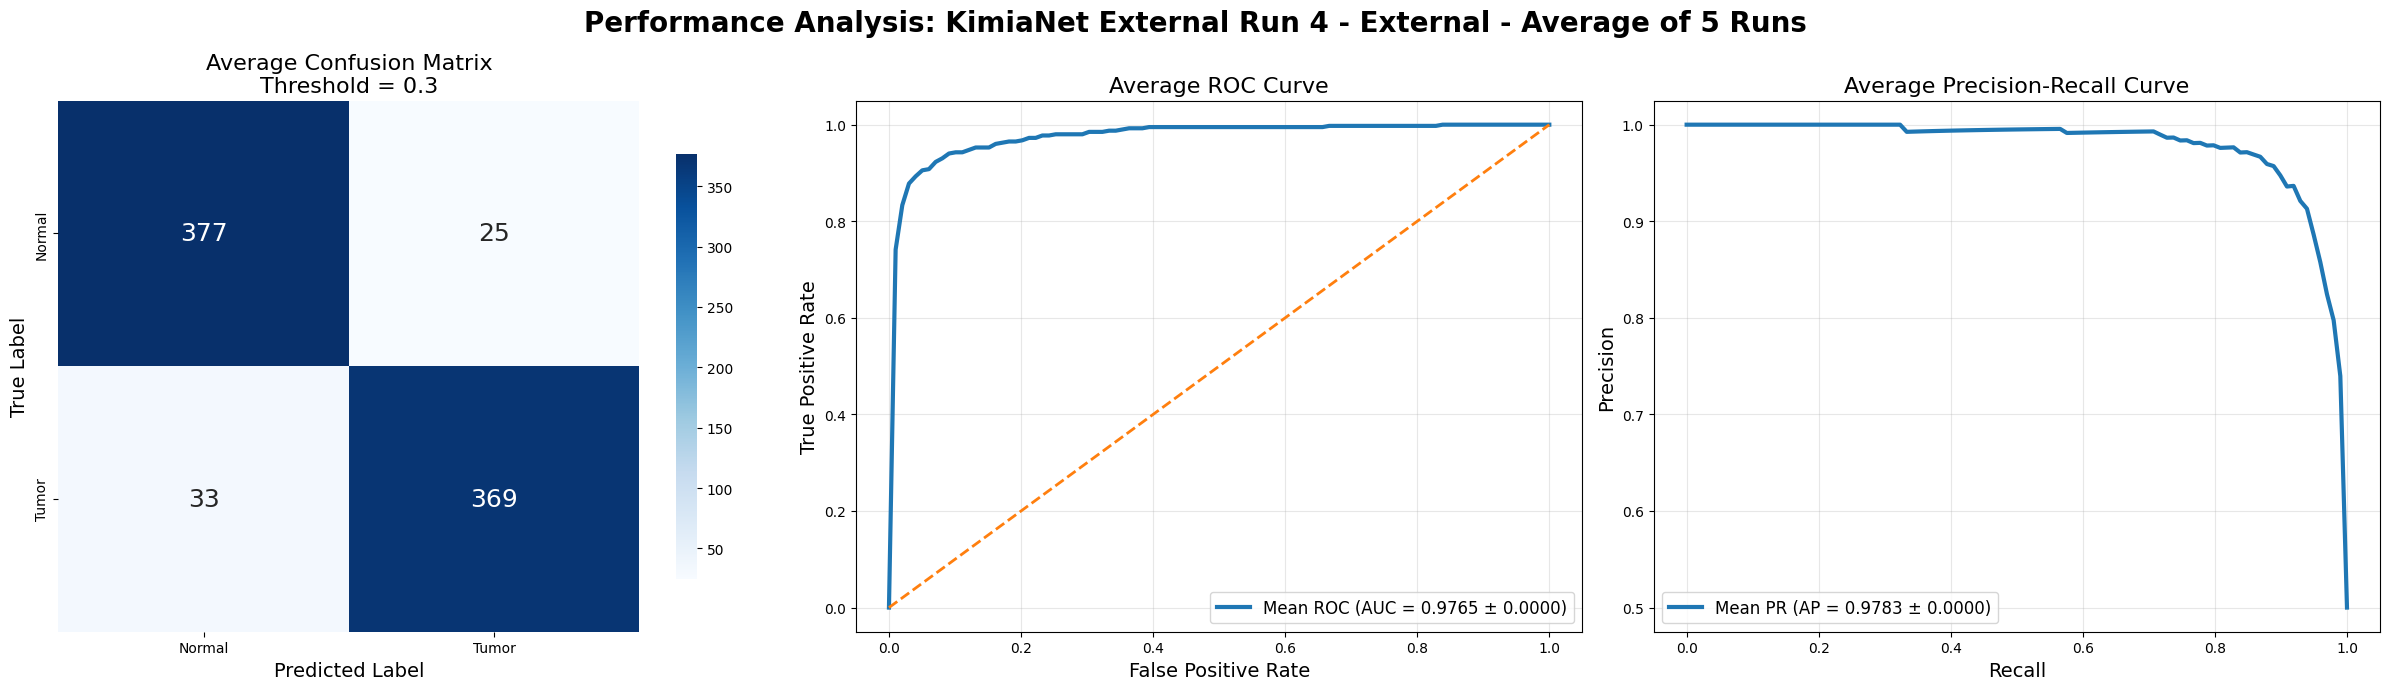


External Test - KimiaNet External Run 5
External test slides: 804

========== KimiaNet External Run 5 - External Test TEST RESULTS ==========
Test Loss   : 1.1401
Test Acc    : 0.8333
Test Prec   : 0.9752
Test Recall : 0.6841
Test Spec   : 0.9826
Test F1     : 0.8041
Test AUC    : 0.9551

Results Table:
        Metric     Value
0         Loss  1.140090
1     Accuracy  0.833333
2  specificity  0.975177
3    Precision  0.982587
4       Recall  0.684080
5     F1-score  0.804094
6          AUC  0.955063


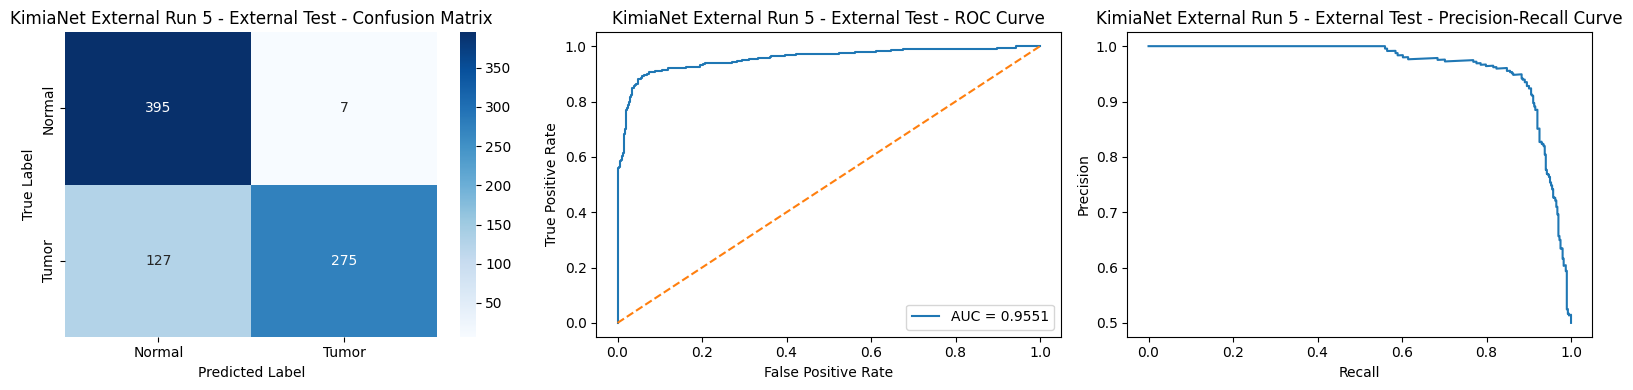

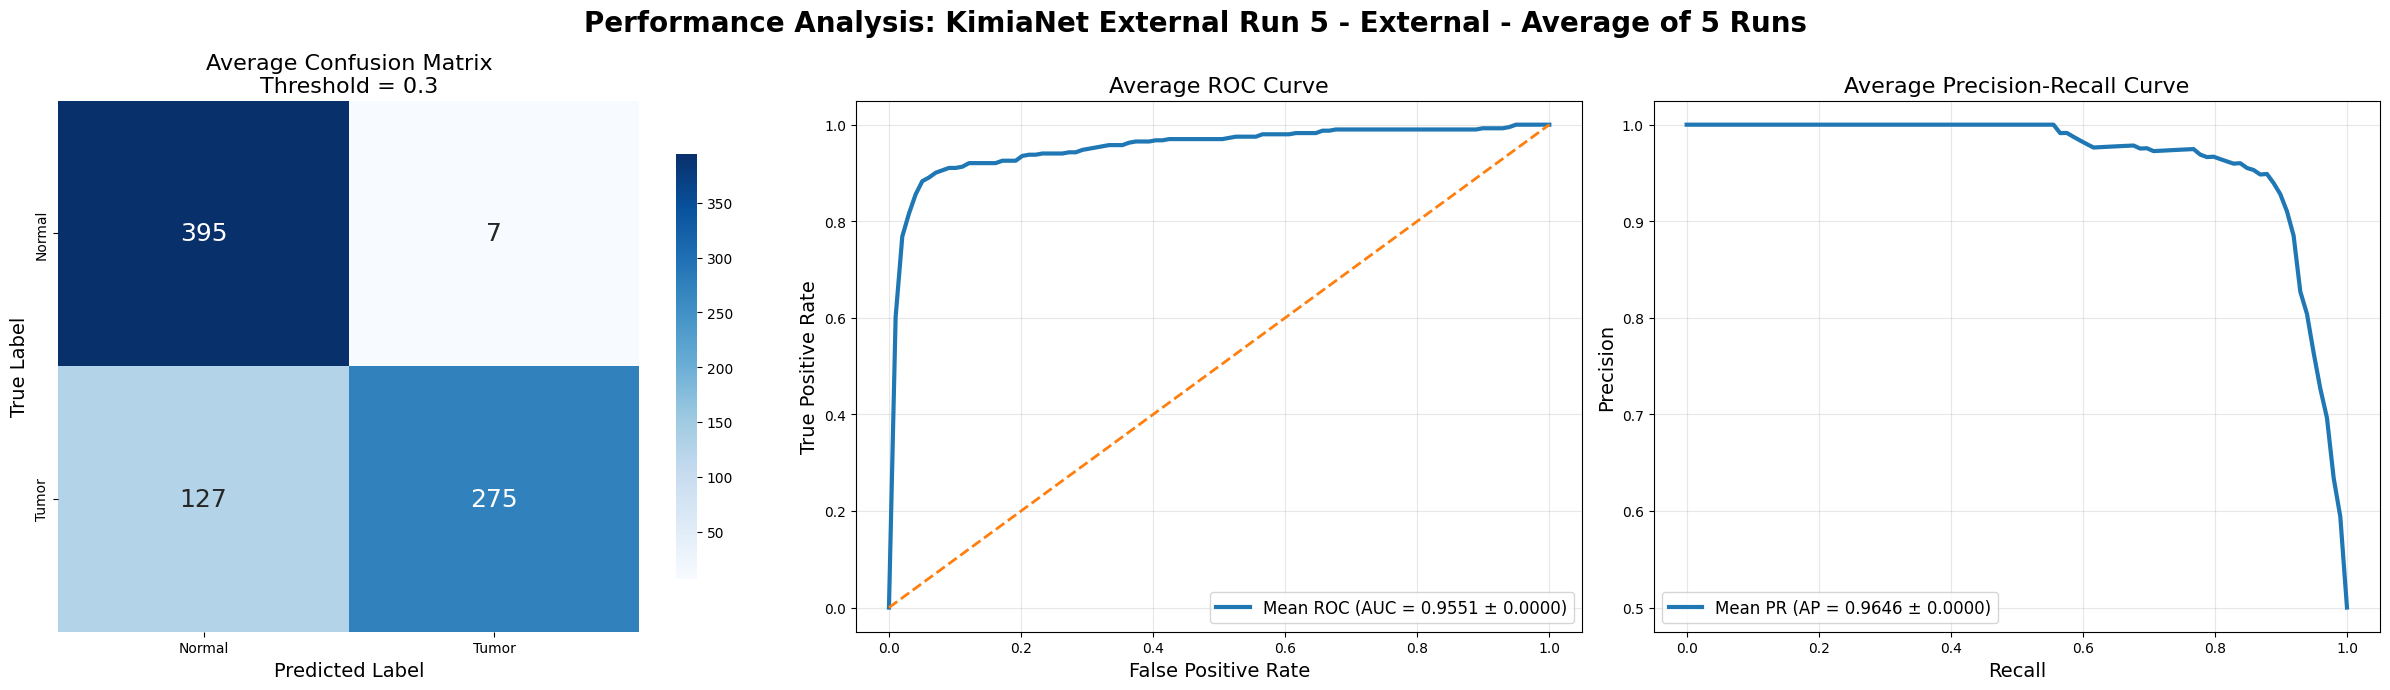


KIMIANET EXTERNAL RESULTS
                 extractor  accuracy  precision  specificity    recall  \
0  KimiaNet External Run 1  0.915423   0.966480     0.970149  0.860697   
1  KimiaNet External Run 2  0.889303   0.975684     0.980100  0.798507   
2  KimiaNet External Run 3  0.891791   0.978723     0.982587  0.800995   
3  KimiaNet External Run 4  0.927861   0.936548     0.937811  0.917910   
4  KimiaNet External Run 5  0.833333   0.975177     0.982587  0.684080   

         f1       auc  run  
0  0.910526  0.975248    1  
1  0.878249  0.976826    2  
2  0.880985  0.980279    3  
3  0.927136  0.976504    4  
4  0.804094  0.955063    5  

KIMIANET EXTERNAL FINAL RESULTS (Mean ± Std)
accuracy    : 0.8915 ± 0.0363
precision   : 0.9665 ± 0.0174
specificity : 0.9706 ± 0.0191
recall      : 0.8124 ± 0.0870
f1          : 0.8802 ± 0.0472
auc         : 0.9728 ± 0.0101


In [ ]:
KIMIANET_EXTERNAL_DIR = "/content/drive/MyDrive/CPTAC-LUAD_kimianet_features"

KIMIANET_MODEL_PATHS = [
    "/content/best_model_kimianet_run1.pth",
    "/content/best_model_kimianet_run2.pth",
    "/content/best_model_kimianet_run3.pth",
    "/content/best_model_kimianet_run4.pth",
    "/content/best_model_kimianet_run5.pth",
]

kimianet_external_runs = []

for i, model_path in enumerate(KIMIANET_MODEL_PATHS, start=1):

    result = external_test_single_extractor(
        extractor_name=f"KimiaNet External Run {i}",
        external_test_dir=KIMIANET_EXTERNAL_DIR,
        input_dim=1024,
        model_path=model_path,
        threshold=0.3
    )

    result["run"] = i

    kimianet_external_runs.append(result)

# =====================================================
# Convert to DataFrame
# =====================================================

kimianet_external_df = pd.DataFrame(kimianet_external_runs)

print("\n" + "="*60)
print("KIMIANET EXTERNAL RESULTS")
print("="*60)

print(kimianet_external_df)

# =====================================================
# Mean ± Std
# =====================================================

print("\n" + "="*60)
print("KIMIANET EXTERNAL FINAL RESULTS (Mean ± Std)")
print("="*60)

for metric in [
    "accuracy",
    "precision",
    "specificity",
    "recall",
    "f1",
    "auc"
]:

    mean = kimianet_external_df[metric].mean()
    std = kimianet_external_df[metric].std()

    print(f"{metric:<12}: {mean:.4f} ± {std:.4f}")


External Test - MobileNet External Run 1
External test slides: 804

========== MobileNet External Run 1 - External Test TEST RESULTS ==========
Test Loss   : 0.2958
Test Acc    : 0.9216
Test Prec   : 0.9721
Test Recall : 0.8682
Test Spec   : 0.9751
Test F1     : 0.9172
Test AUC    : 0.9754

Results Table:
        Metric     Value
0         Loss  0.295757
1     Accuracy  0.921642
2  specificity  0.972145
3    Precision  0.975124
4       Recall  0.868159
5     F1-score  0.917214
6          AUC  0.975421


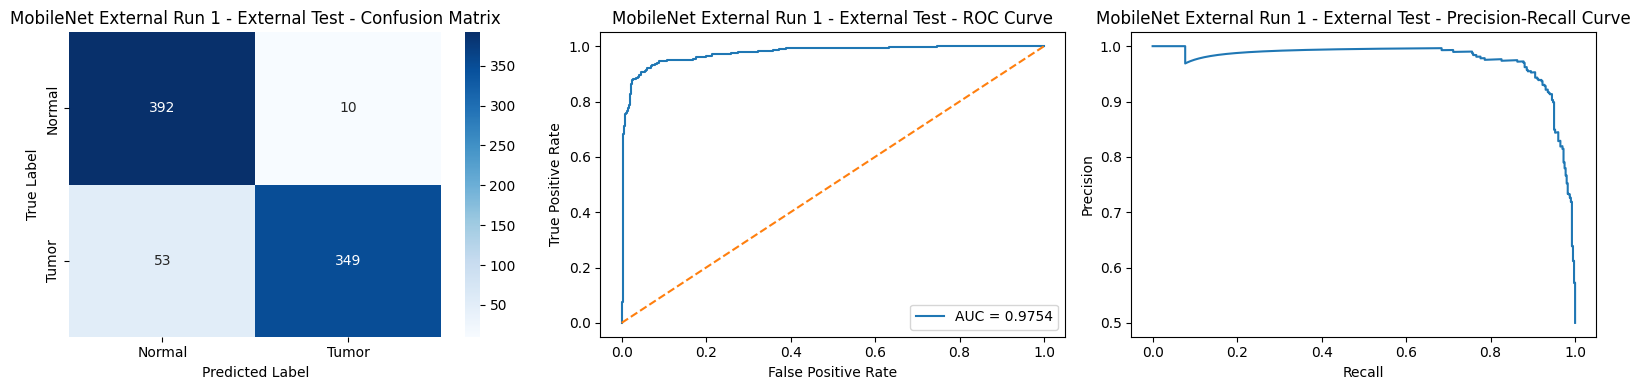

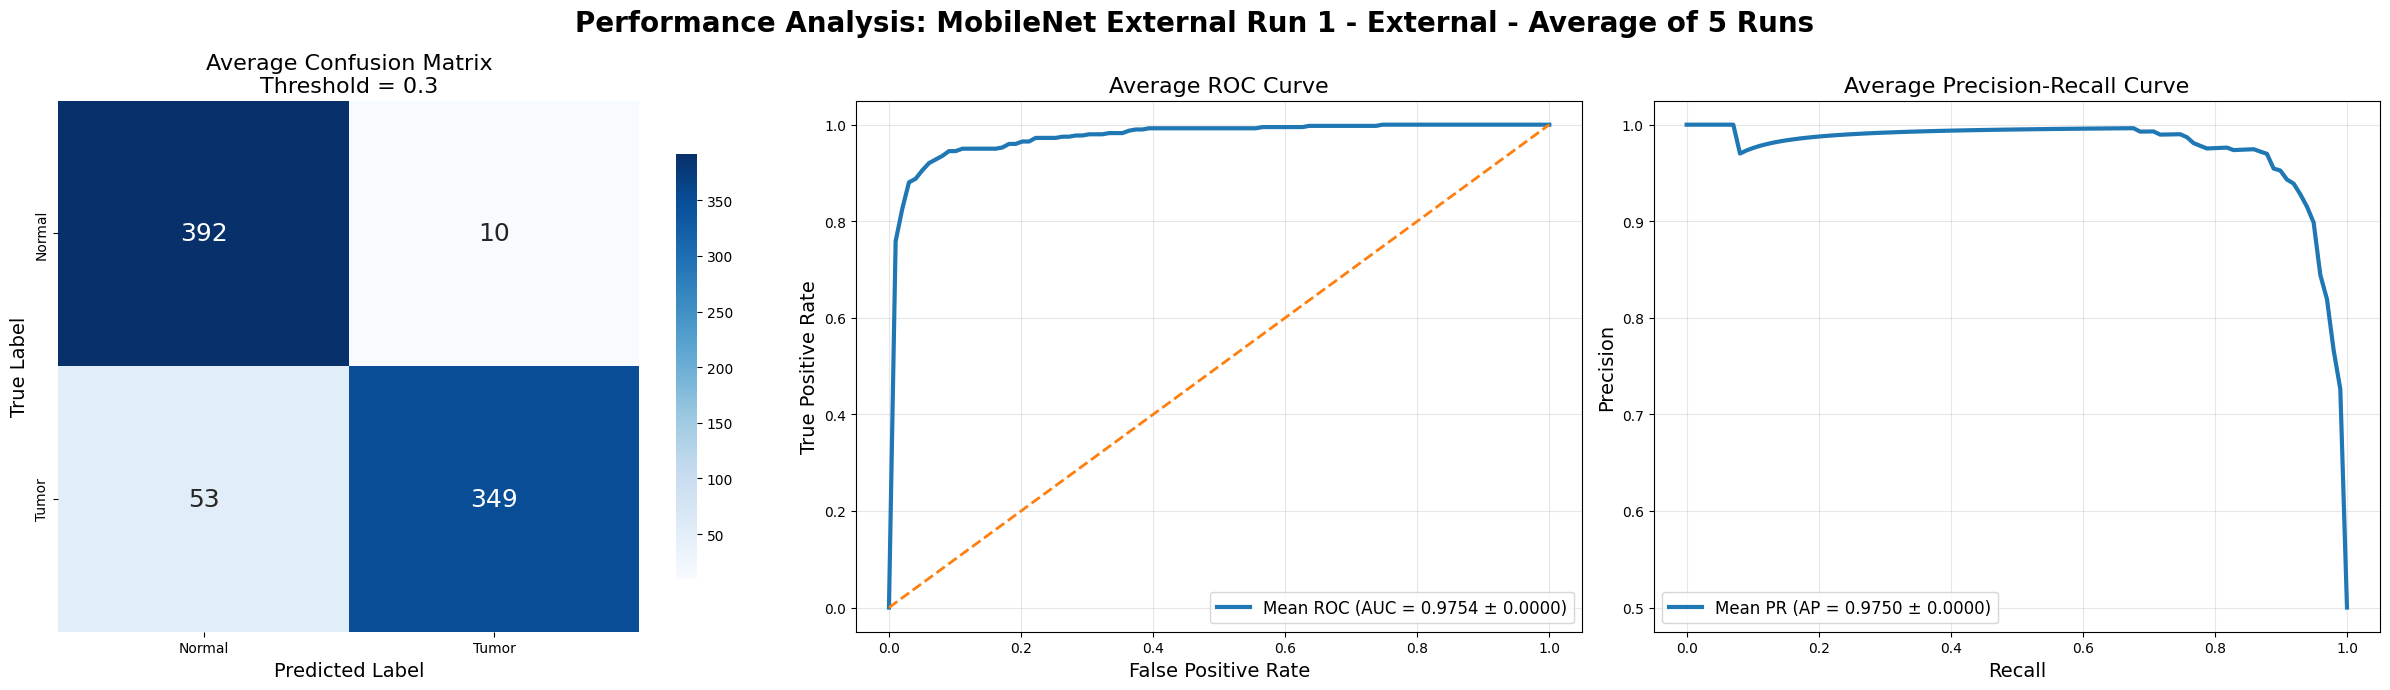


External Test - MobileNet External Run 2
External test slides: 804

========== MobileNet External Run 2 - External Test TEST RESULTS ==========
Test Loss   : 0.4441
Test Acc    : 0.8781
Test Prec   : 0.9720
Test Recall : 0.7786
Test Spec   : 0.9776
Test F1     : 0.8646
Test AUC    : 0.9752

Results Table:
        Metric     Value
0         Loss  0.444123
1     Accuracy  0.878109
2  specificity  0.972050
3    Precision  0.977612
4       Recall  0.778607
5     F1-score  0.864641
6          AUC  0.975223


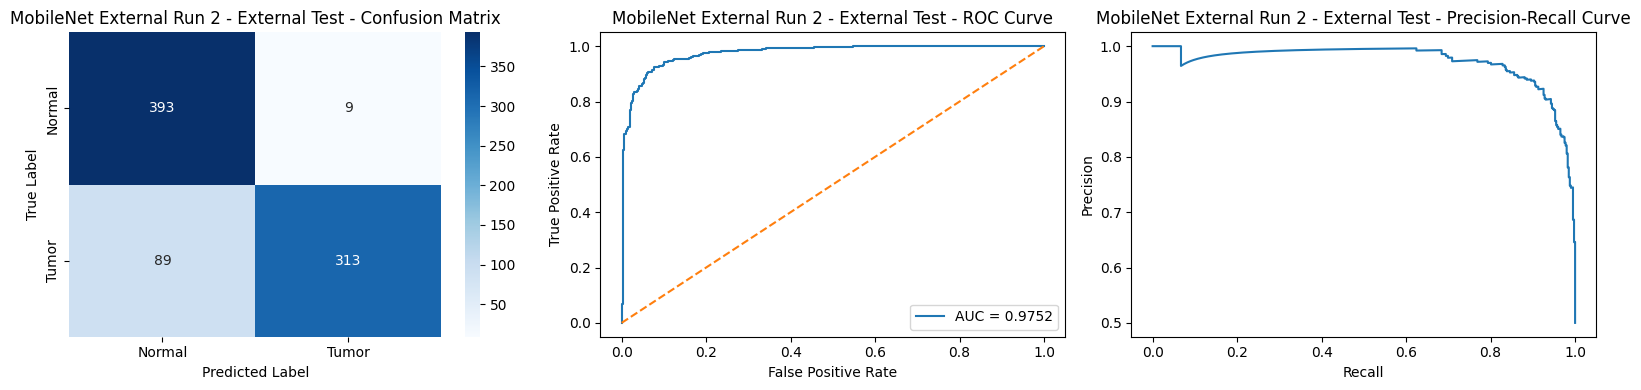

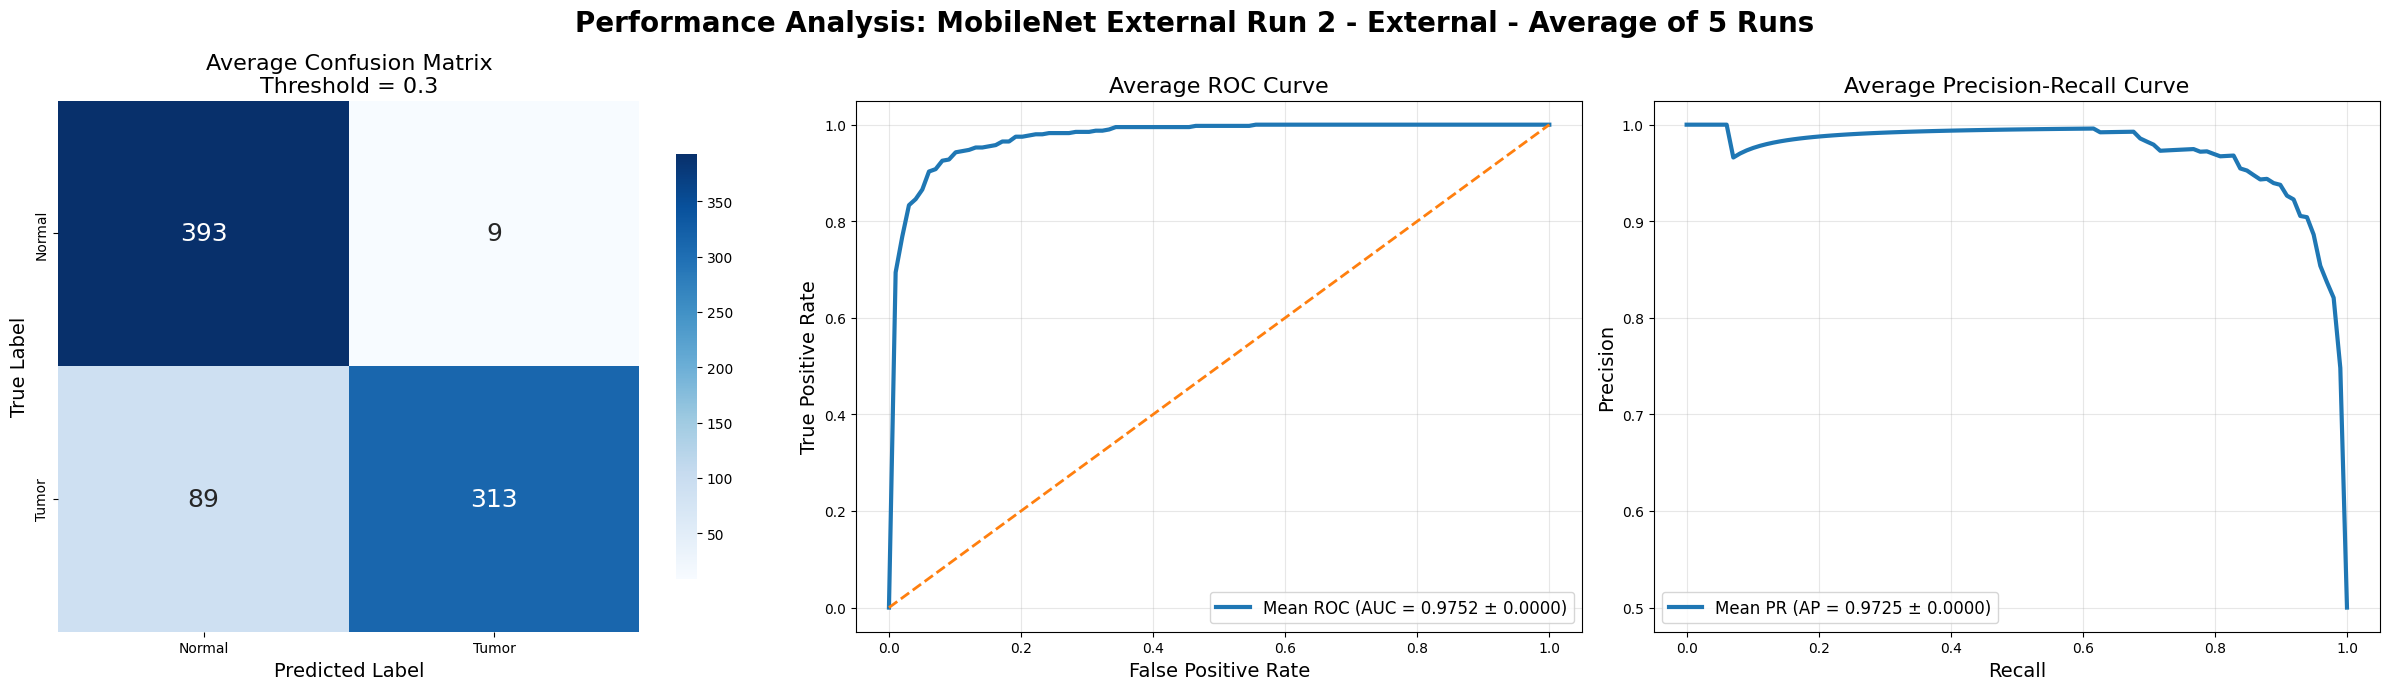


External Test - MobileNet External Run 3
External test slides: 804

========== MobileNet External Run 3 - External Test TEST RESULTS ==========
Test Loss   : 0.2175
Test Acc    : 0.9241
Test Prec   : 0.9189
Test Recall : 0.9303
Test Spec   : 0.9179
Test F1     : 0.9246
Test AUC    : 0.9736

Results Table:
        Metric     Value
0         Loss  0.217541
1     Accuracy  0.924129
2  specificity  0.918919
3    Precision  0.917910
4       Recall  0.930348
5     F1-score  0.924598
6          AUC  0.973627


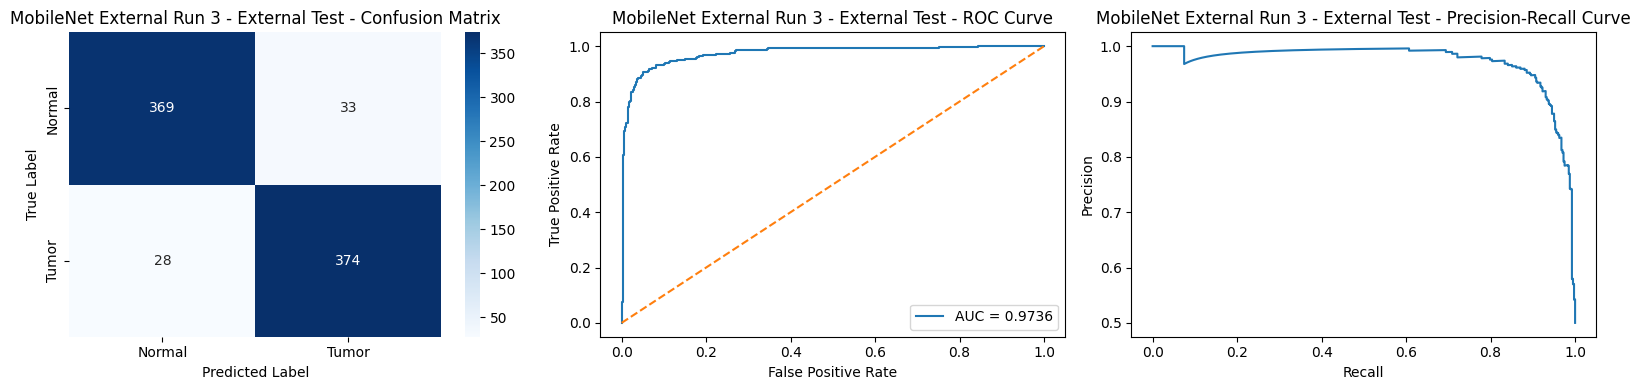

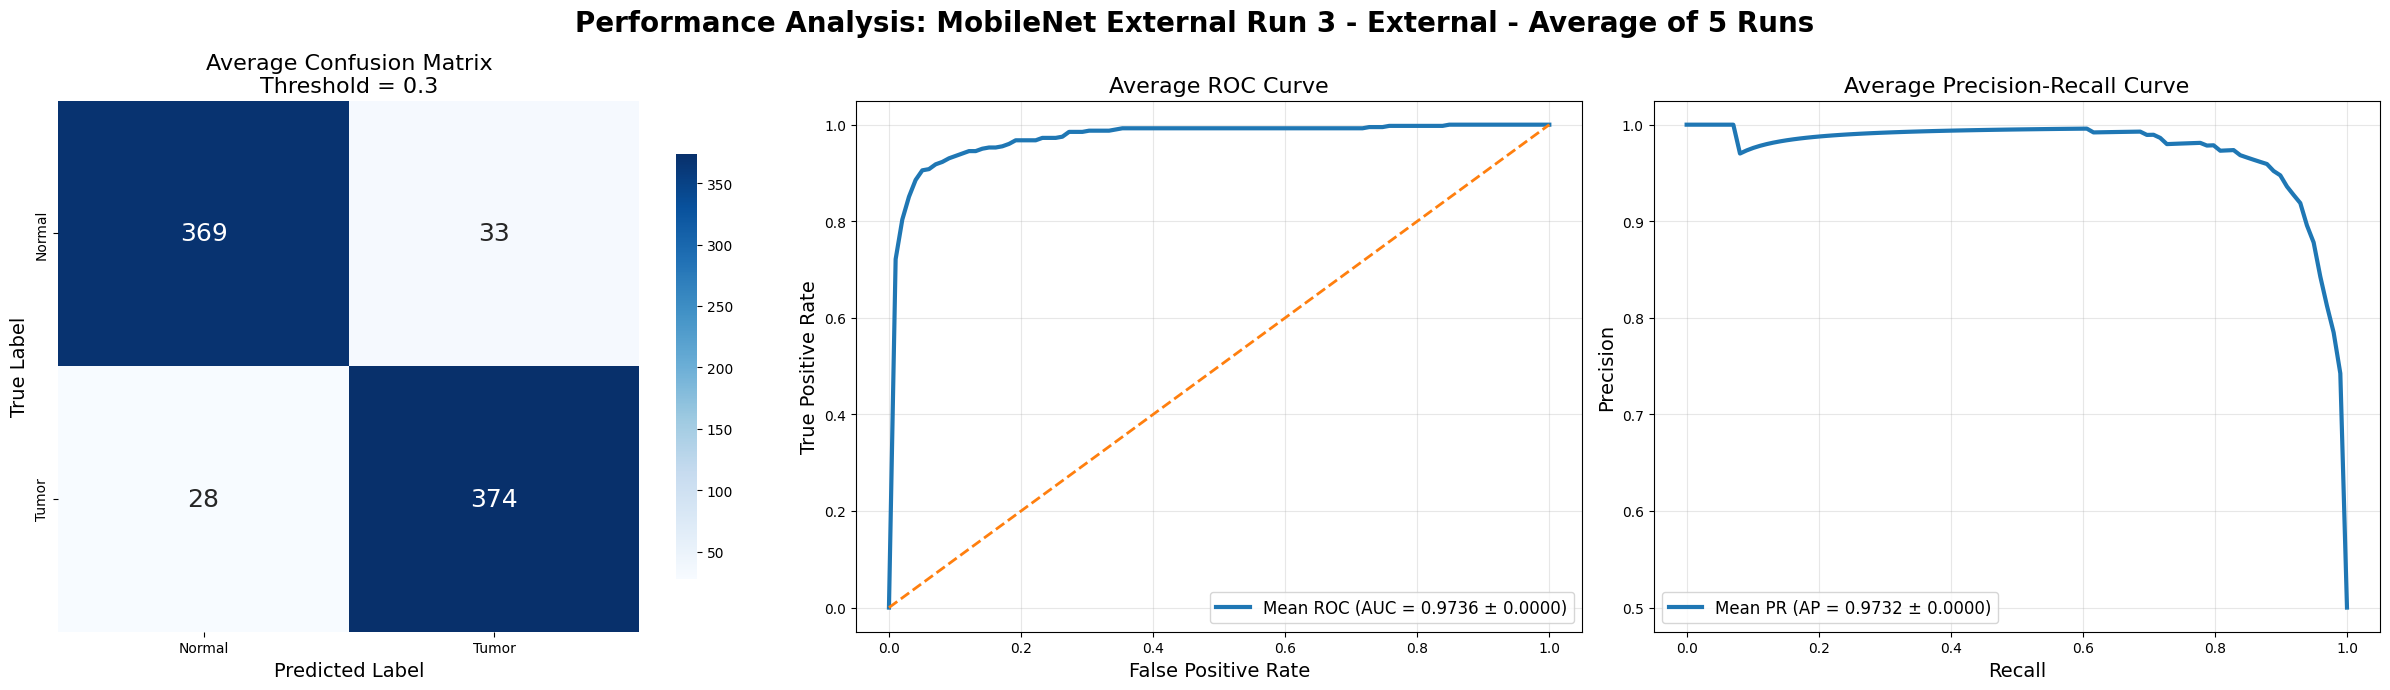


External Test - MobileNet External Run 4
External test slides: 804

========== MobileNet External Run 4 - External Test TEST RESULTS ==========
Test Loss   : 0.1855
Test Acc    : 0.9303
Test Prec   : 0.9100
Test Recall : 0.9552
Test Spec   : 0.9055
Test F1     : 0.9320
Test AUC    : 0.9809

Results Table:
        Metric     Value
0         Loss  0.185543
1     Accuracy  0.930348
2  specificity  0.909953
3    Precision  0.905473
4       Recall  0.955224
5     F1-score  0.932039
6          AUC  0.980879


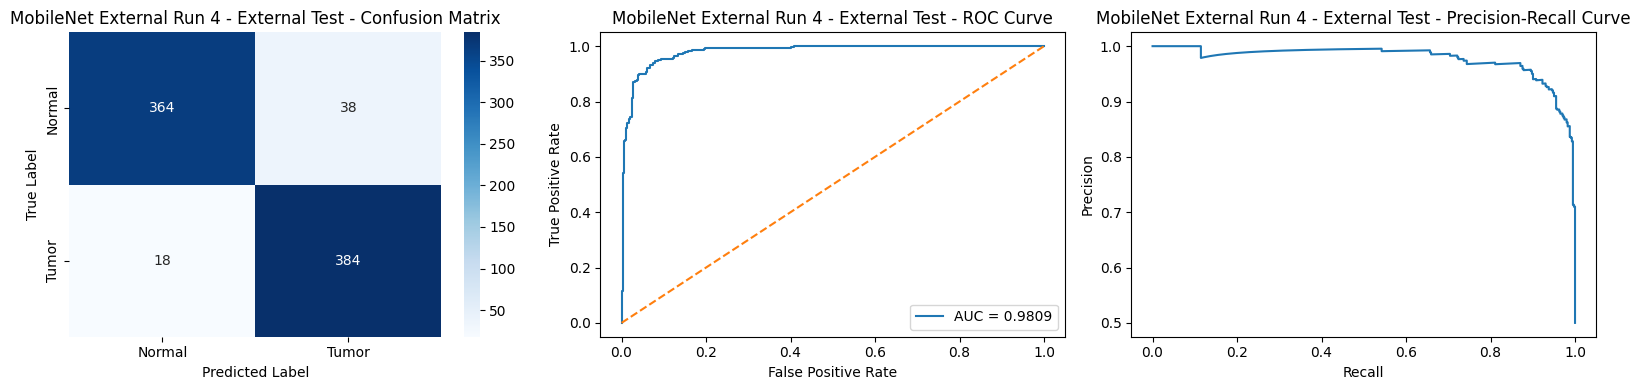

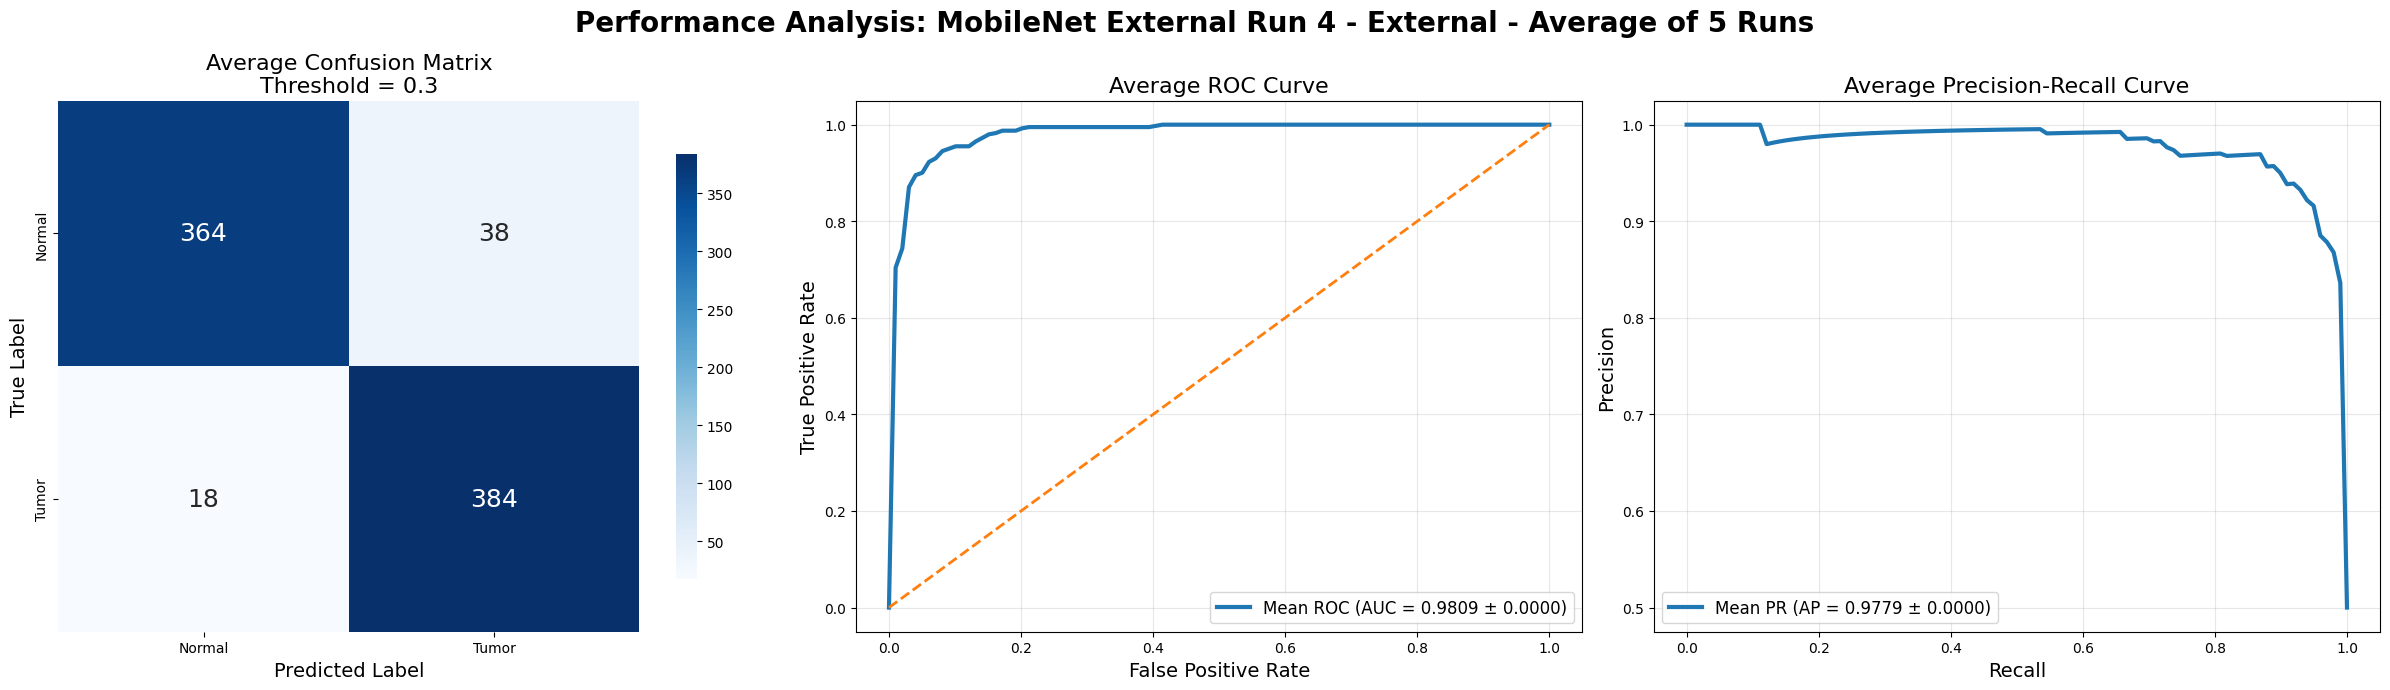


External Test - MobileNet External Run 5
External test slides: 804

========== MobileNet External Run 5 - External Test TEST RESULTS ==========
Test Loss   : 0.2453
Test Acc    : 0.9179
Test Prec   : 0.9421
Test Recall : 0.8905
Test Spec   : 0.9453
Test F1     : 0.9156
Test AUC    : 0.9774

Results Table:
        Metric     Value
0         Loss  0.245288
1     Accuracy  0.917910
2  specificity  0.942105
3    Precision  0.945274
4       Recall  0.890547
5     F1-score  0.915601
6          AUC  0.977408


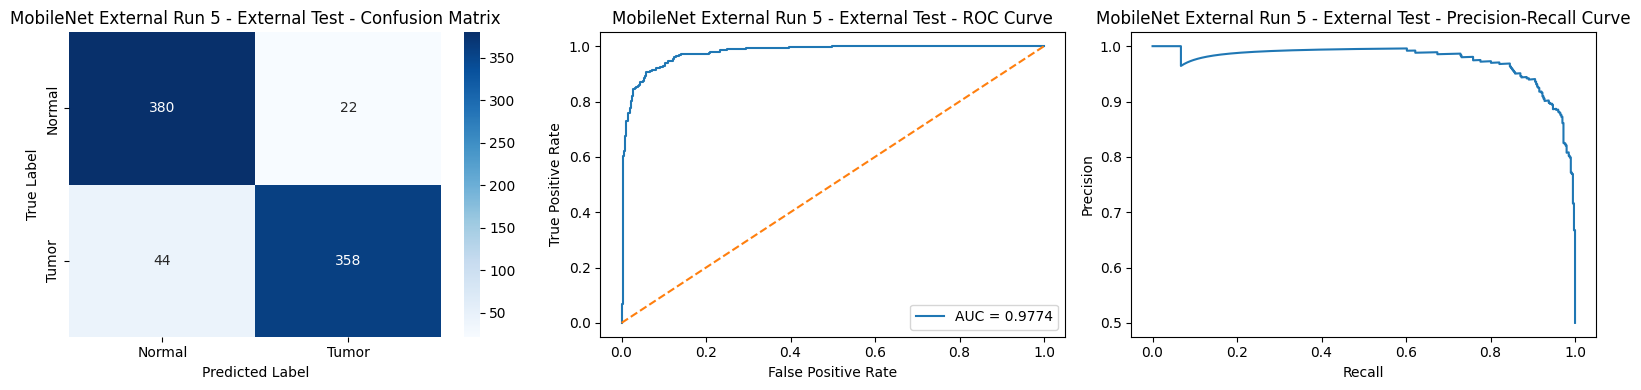

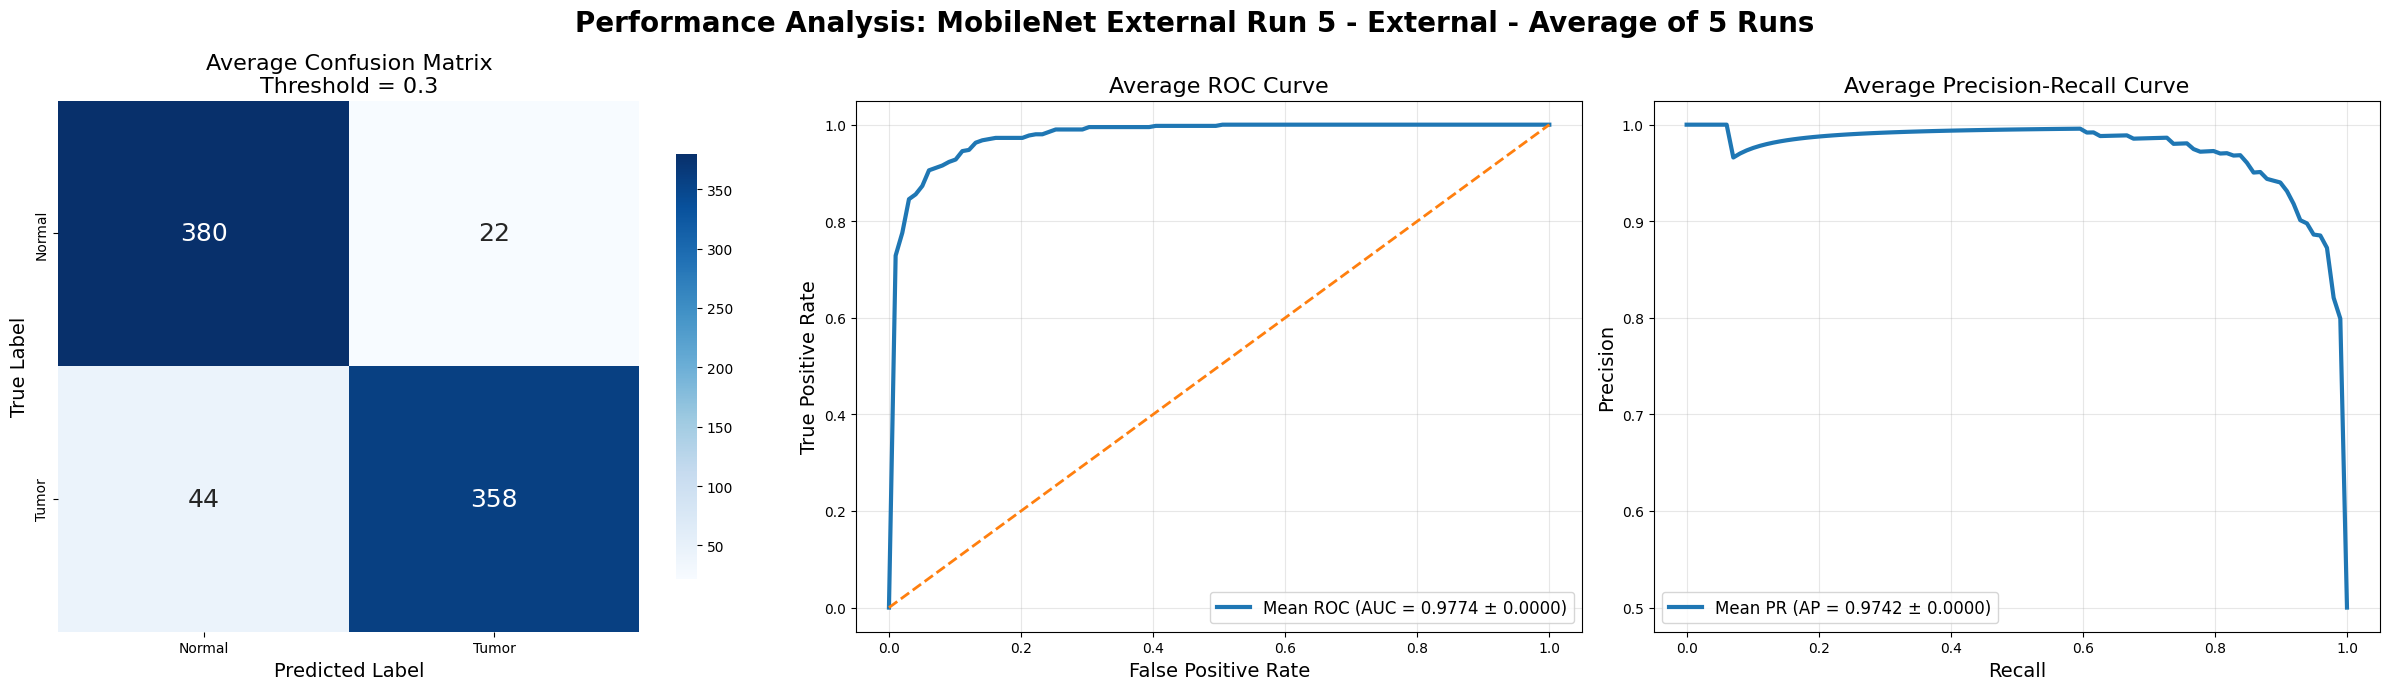


MOBILENET EXTERNAL RESULTS
                  extractor  accuracy  precision  specificity    recall  \
0  MobileNet External Run 1  0.921642   0.972145     0.975124  0.868159   
1  MobileNet External Run 2  0.878109   0.972050     0.977612  0.778607   
2  MobileNet External Run 3  0.924129   0.918919     0.917910  0.930348   
3  MobileNet External Run 4  0.930348   0.909953     0.905473  0.955224   
4  MobileNet External Run 5  0.917910   0.942105     0.945274  0.890547   

         f1       auc  run  
0  0.917214  0.975421    1  
1  0.864641  0.975223    2  
2  0.924598  0.973627    3  
3  0.932039  0.980879    4  
4  0.915601  0.977408    5  

MOBILENET EXTERNAL FINAL RESULTS (Mean ± Std)
accuracy    : 0.9144 ± 0.0208
precision   : 0.9430 ± 0.0290
specificity : 0.9443 ± 0.0327
recall      : 0.8846 ± 0.0682
f1          : 0.9108 ± 0.0266
auc         : 0.9765 ± 0.0028


In [ ]:
MOBILENET_EXTERNAL_DIR = "/content/drive/MyDrive/CPTAC-LUAD_MobileNet_features"

MOBILENET_MODEL_PATHS = [
    "/content/best_model_mobilenet_run1.pth",
    "/content/best_model_mobilenet_run2.pth",
    "/content/best_model_mobilenet_run3.pth",
    "/content/best_model_mobilenet_run4.pth",
    "/content/best_model_mobilenet_run5.pth",
]
mobilenet_external_runs = []

for i, model_path in enumerate(MOBILENET_MODEL_PATHS, start=1):

    result = external_test_single_extractor(
        extractor_name=f"MobileNet External Run {i}",
        external_test_dir=MOBILENET_EXTERNAL_DIR,
        input_dim=1280,
        model_path=model_path,
        threshold=0.3
    )

    result["run"] = i
    mobilenet_external_runs.append(result)

mobilenet_external_df = pd.DataFrame(mobilenet_external_runs)

print("\n" + "="*60)
print("MOBILENET EXTERNAL RESULTS")
print("="*60)
print(mobilenet_external_df)

print("\n" + "="*60)
print("MOBILENET EXTERNAL FINAL RESULTS (Mean ± Std)")
print("="*60)

for metric in ["accuracy", "precision", "specificity", "recall", "f1", "auc"]:
    mean = mobilenet_external_df[metric].mean()
    std = mobilenet_external_df[metric].std()
    print(f"{metric:<12}: {mean:.4f} ± {std:.4f}")


External Test - CTransPath External Run 1
External test slides: 804

========== CTransPath External Run 1 - External Test TEST RESULTS ==========
Test Loss   : 0.2456
Test Acc    : 0.9316
Test Prec   : 0.9860
Test Recall : 0.8756
Test Spec   : 0.9876
Test F1     : 0.9275
Test AUC    : 0.9912

Results Table:
        Metric     Value
0         Loss  0.245640
1     Accuracy  0.931592
2  specificity  0.985994
3    Precision  0.987562
4       Recall  0.875622
5     F1-score  0.927536
6          AUC  0.991195


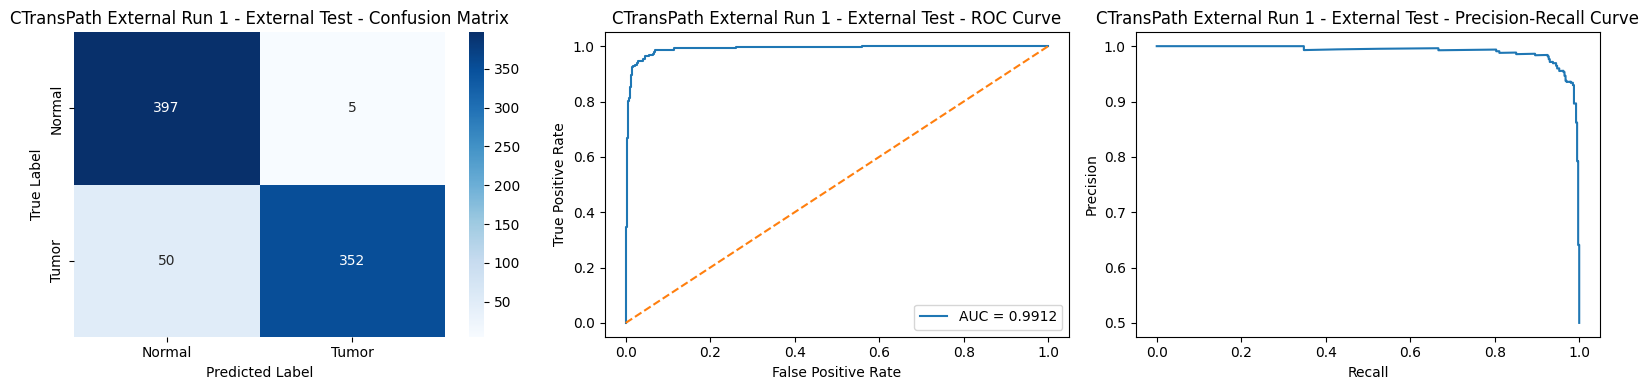

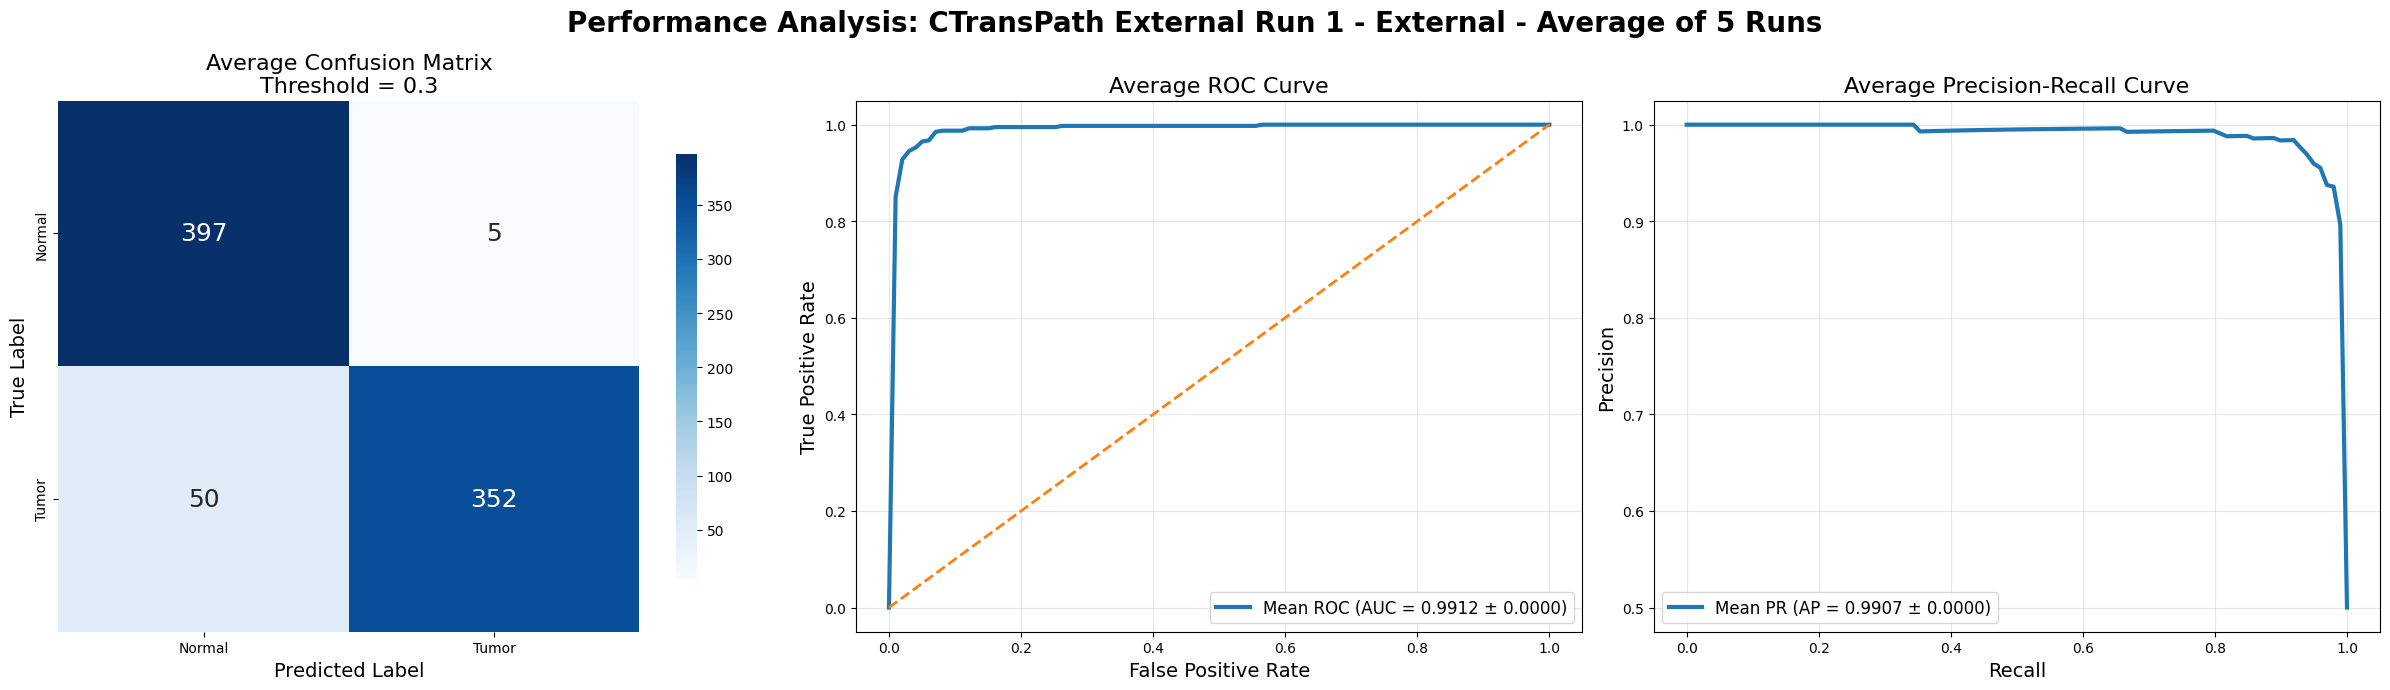


External Test - CTransPath External Run 2
External test slides: 804

========== CTransPath External Run 2 - External Test TEST RESULTS ==========
Test Loss   : 0.4317
Test Acc    : 0.8794
Test Prec   : 0.9935
Test Recall : 0.7637
Test Spec   : 0.9950
Test F1     : 0.8636
Test AUC    : 0.9876

Results Table:
        Metric     Value
0         Loss  0.431670
1     Accuracy  0.879353
2  specificity  0.993528
3    Precision  0.995025
4       Recall  0.763682
5     F1-score  0.863572
6          AUC  0.987556


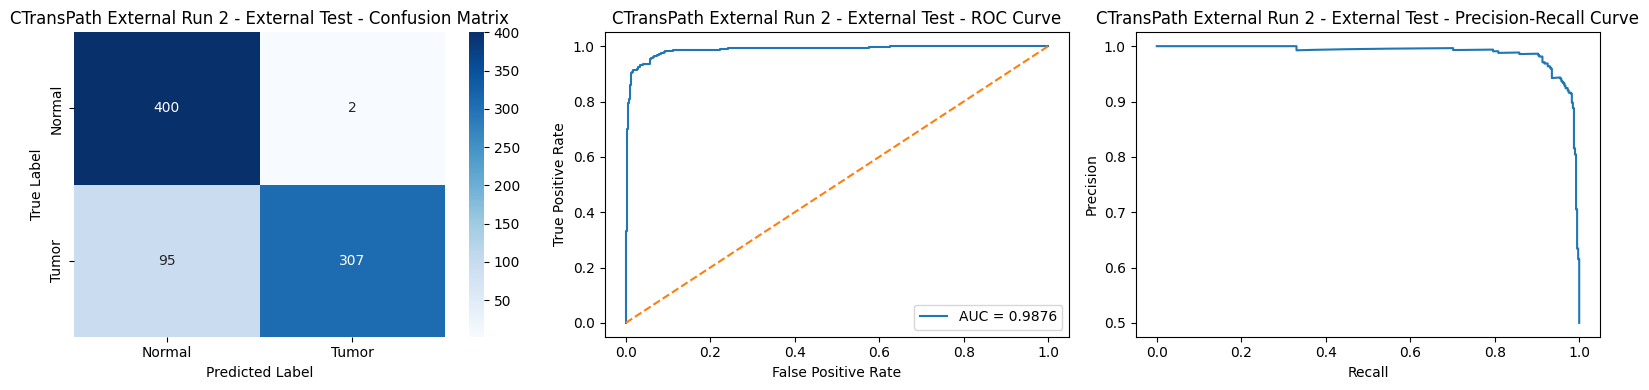

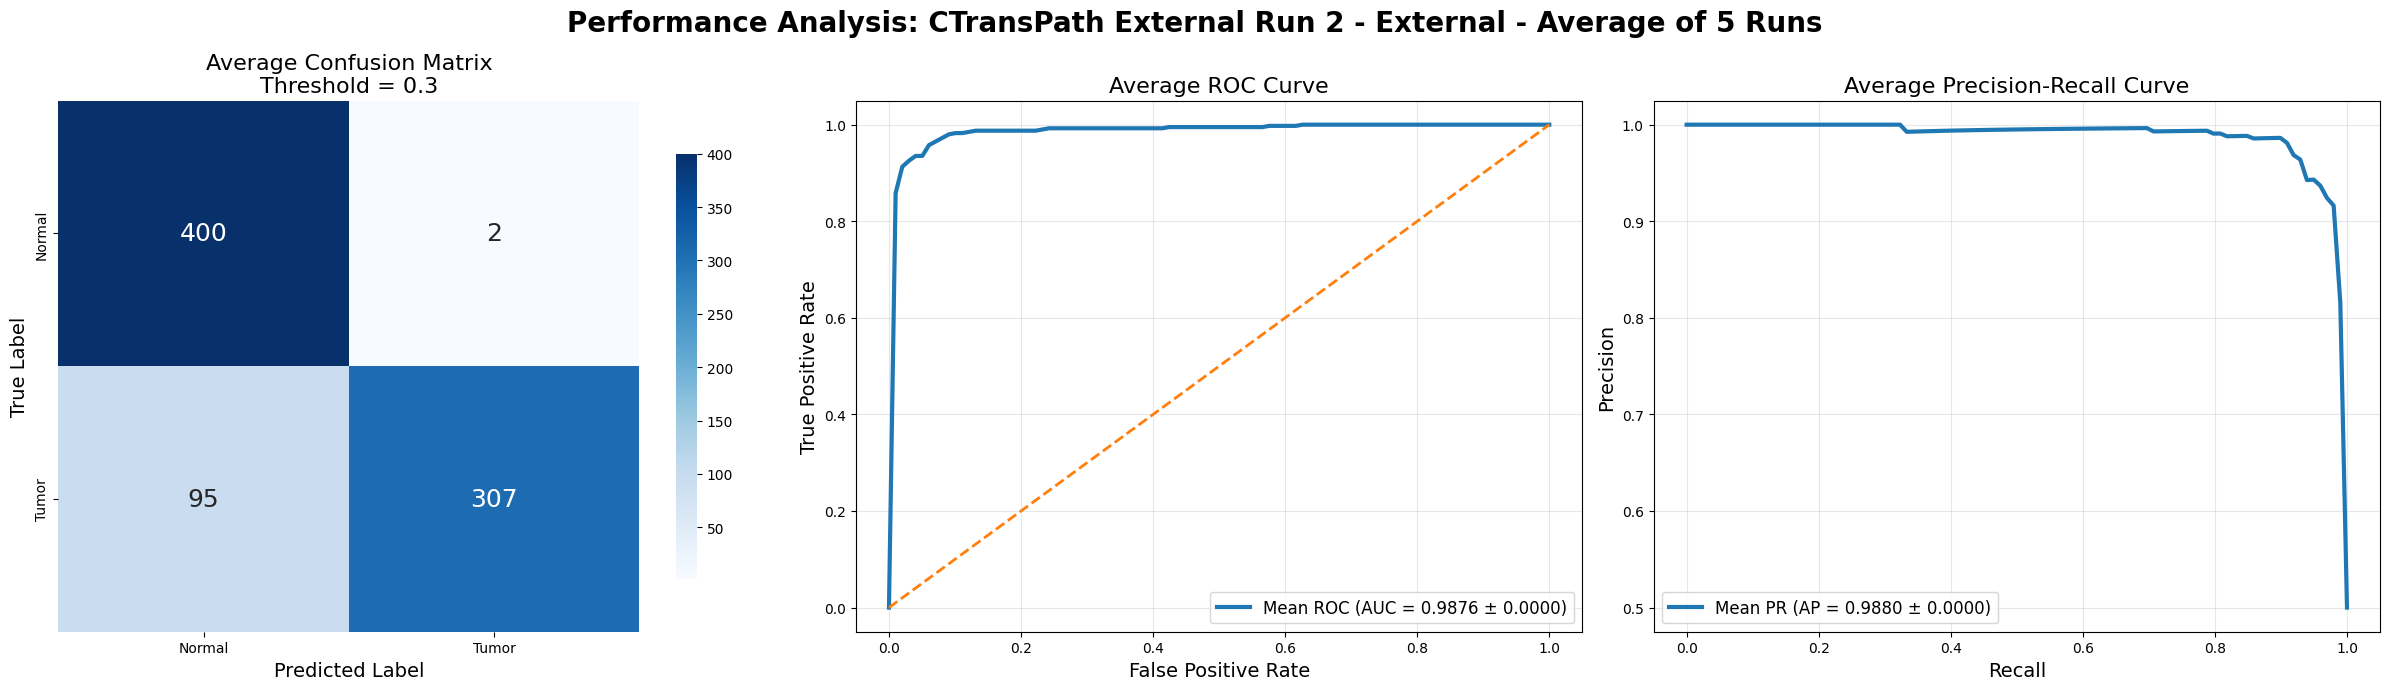


External Test - CTransPath External Run 3
External test slides: 804

========== CTransPath External Run 3 - External Test TEST RESULTS ==========
Test Loss   : 0.4800
Test Acc    : 0.8794
Test Prec   : 0.9935
Test Recall : 0.7637
Test Spec   : 0.9950
Test F1     : 0.8636
Test AUC    : 0.9870

Results Table:
        Metric     Value
0         Loss  0.480042
1     Accuracy  0.879353
2  specificity  0.993528
3    Precision  0.995025
4       Recall  0.763682
5     F1-score  0.863572
6          AUC  0.987049


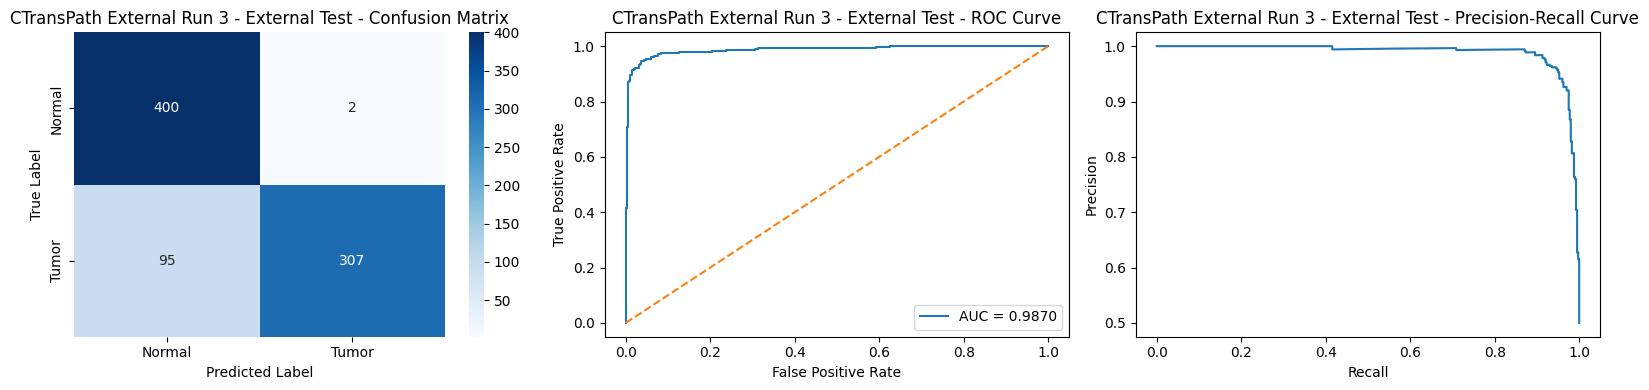

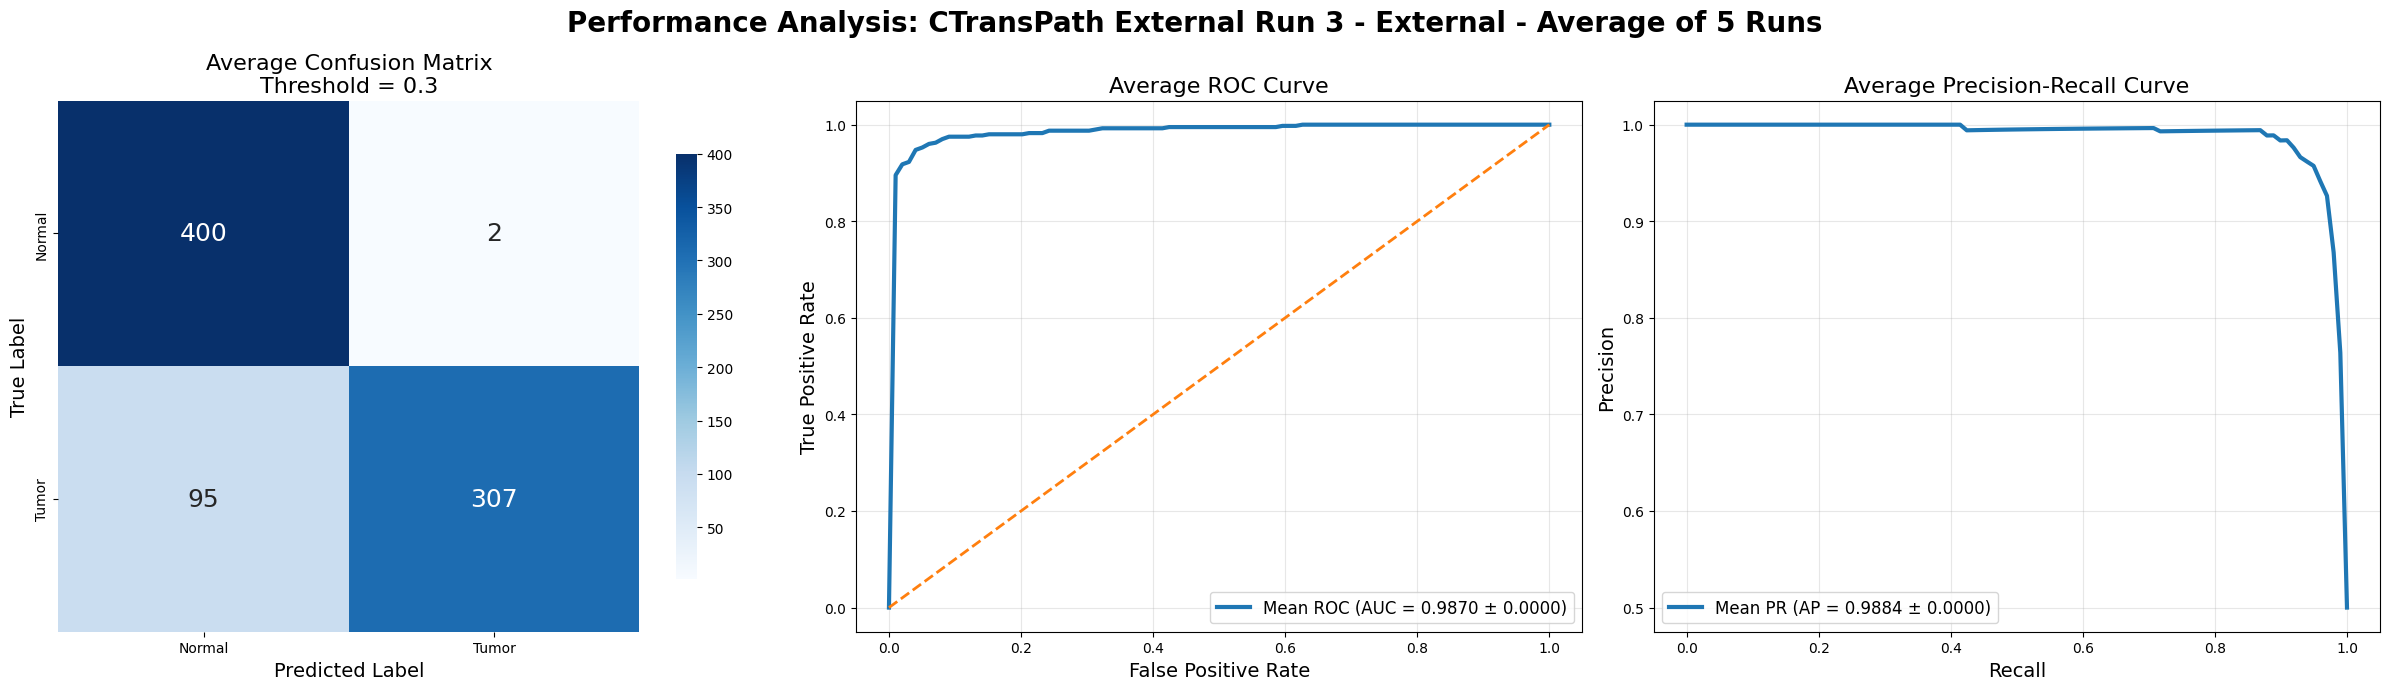


External Test - CTransPath External Run 4
External test slides: 804

========== CTransPath External Run 4 - External Test TEST RESULTS ==========
Test Loss   : 1.5600
Test Acc    : 0.7761
Test Prec   : 0.9955
Test Recall : 0.5547
Test Spec   : 0.9975
Test F1     : 0.7125
Test AUC    : 0.9385

Results Table:
        Metric     Value
0         Loss  1.560010
1     Accuracy  0.776119
2  specificity  0.995536
3    Precision  0.997512
4       Recall  0.554726
5     F1-score  0.712460
6          AUC  0.938535


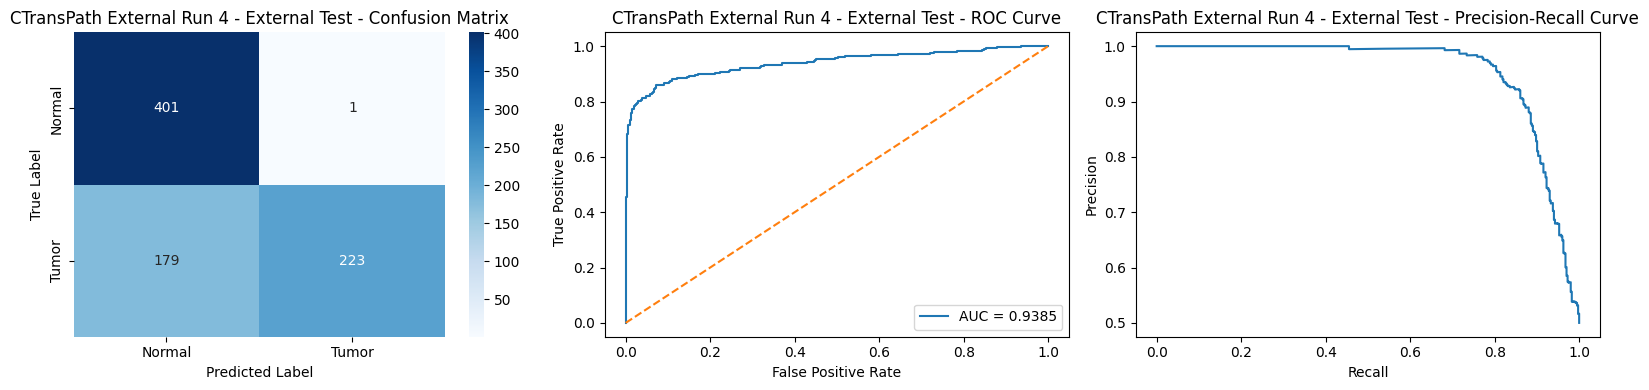

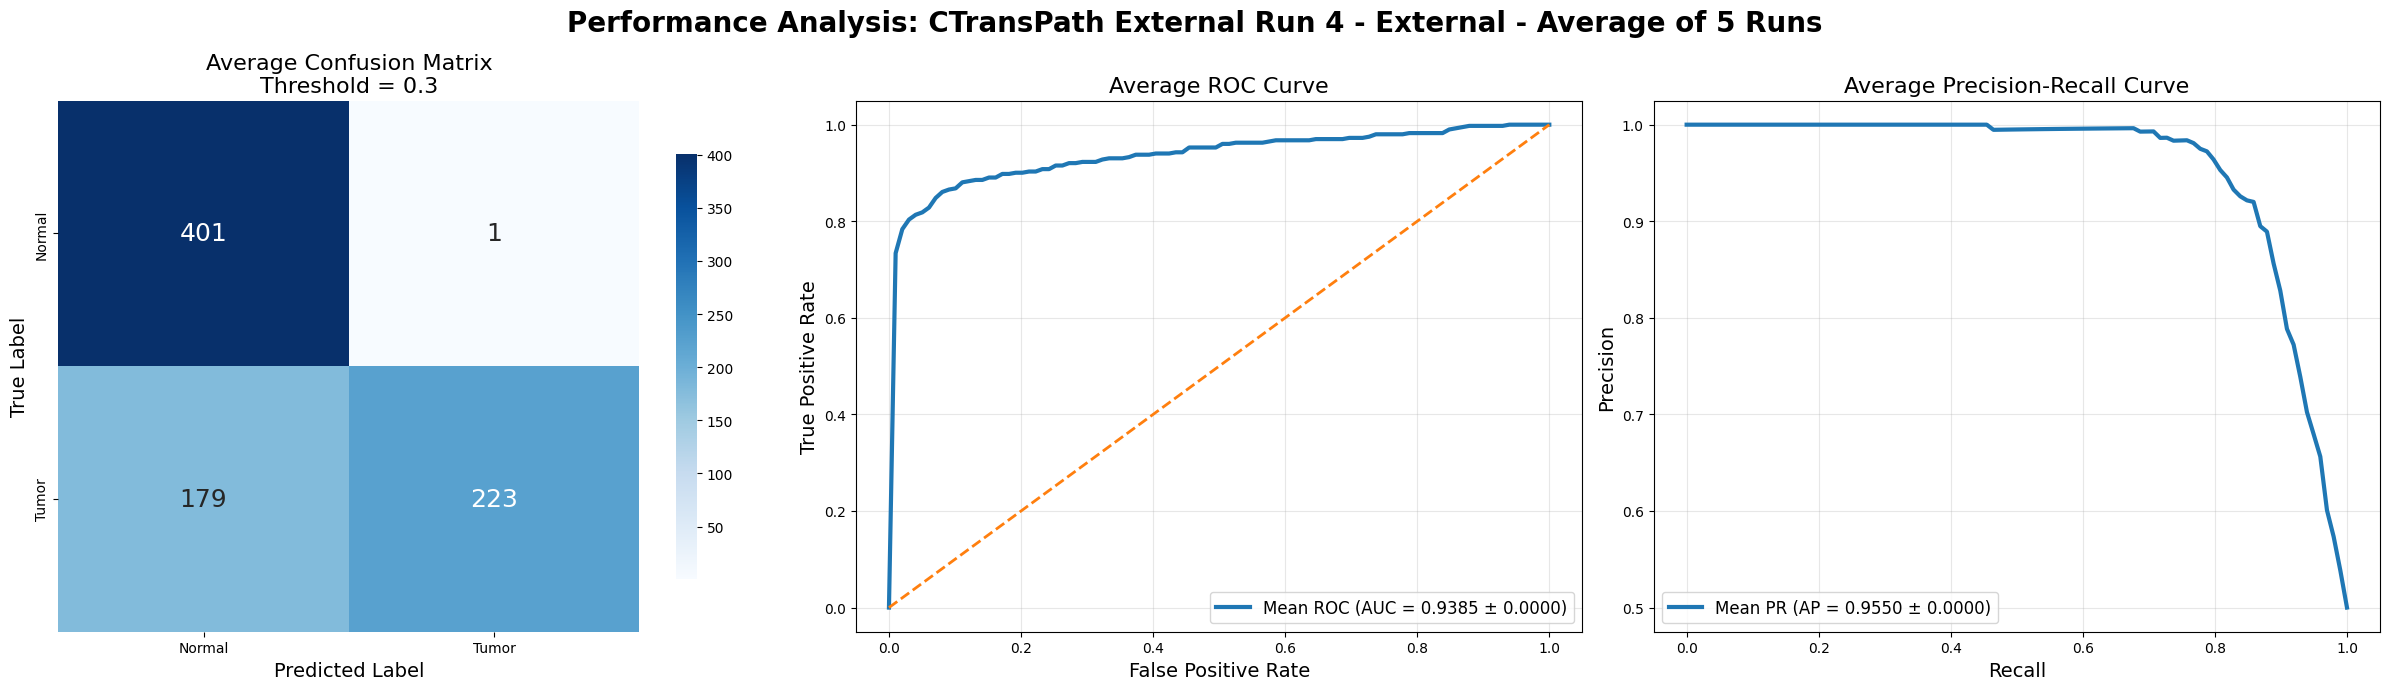


External Test - CTransPath External Run 5
External test slides: 804

========== CTransPath External Run 5 - External Test TEST RESULTS ==========
Test Loss   : 0.5148
Test Acc    : 0.8644
Test Prec   : 0.9966
Test Recall : 0.7313
Test Spec   : 0.9975
Test F1     : 0.8436
Test AUC    : 0.9842

Results Table:
        Metric     Value
0         Loss  0.514771
1     Accuracy  0.864428
2  specificity  0.996610
3    Precision  0.997512
4       Recall  0.731343
5     F1-score  0.843615
6          AUC  0.984190


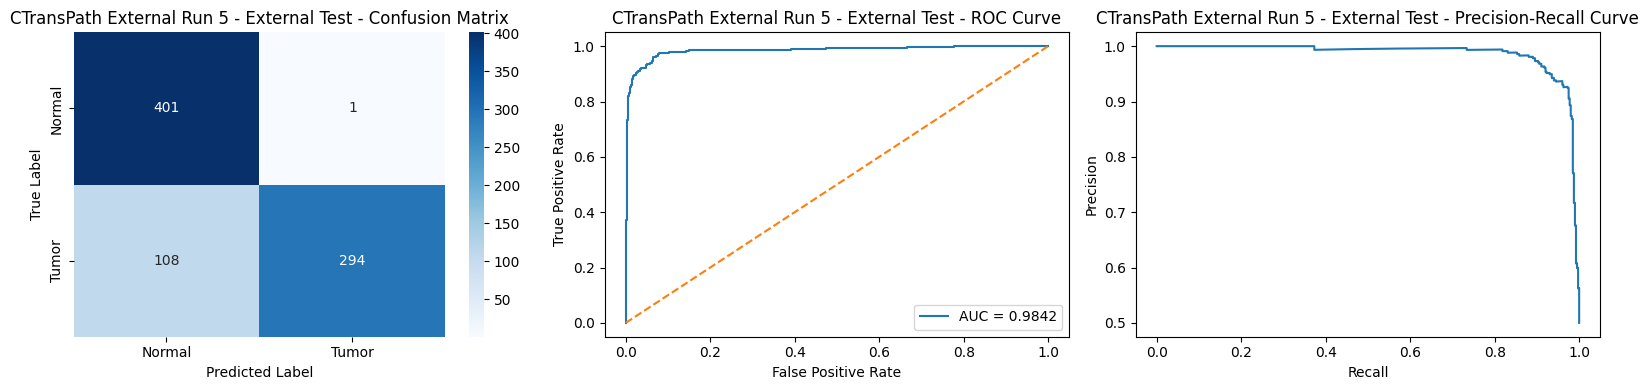

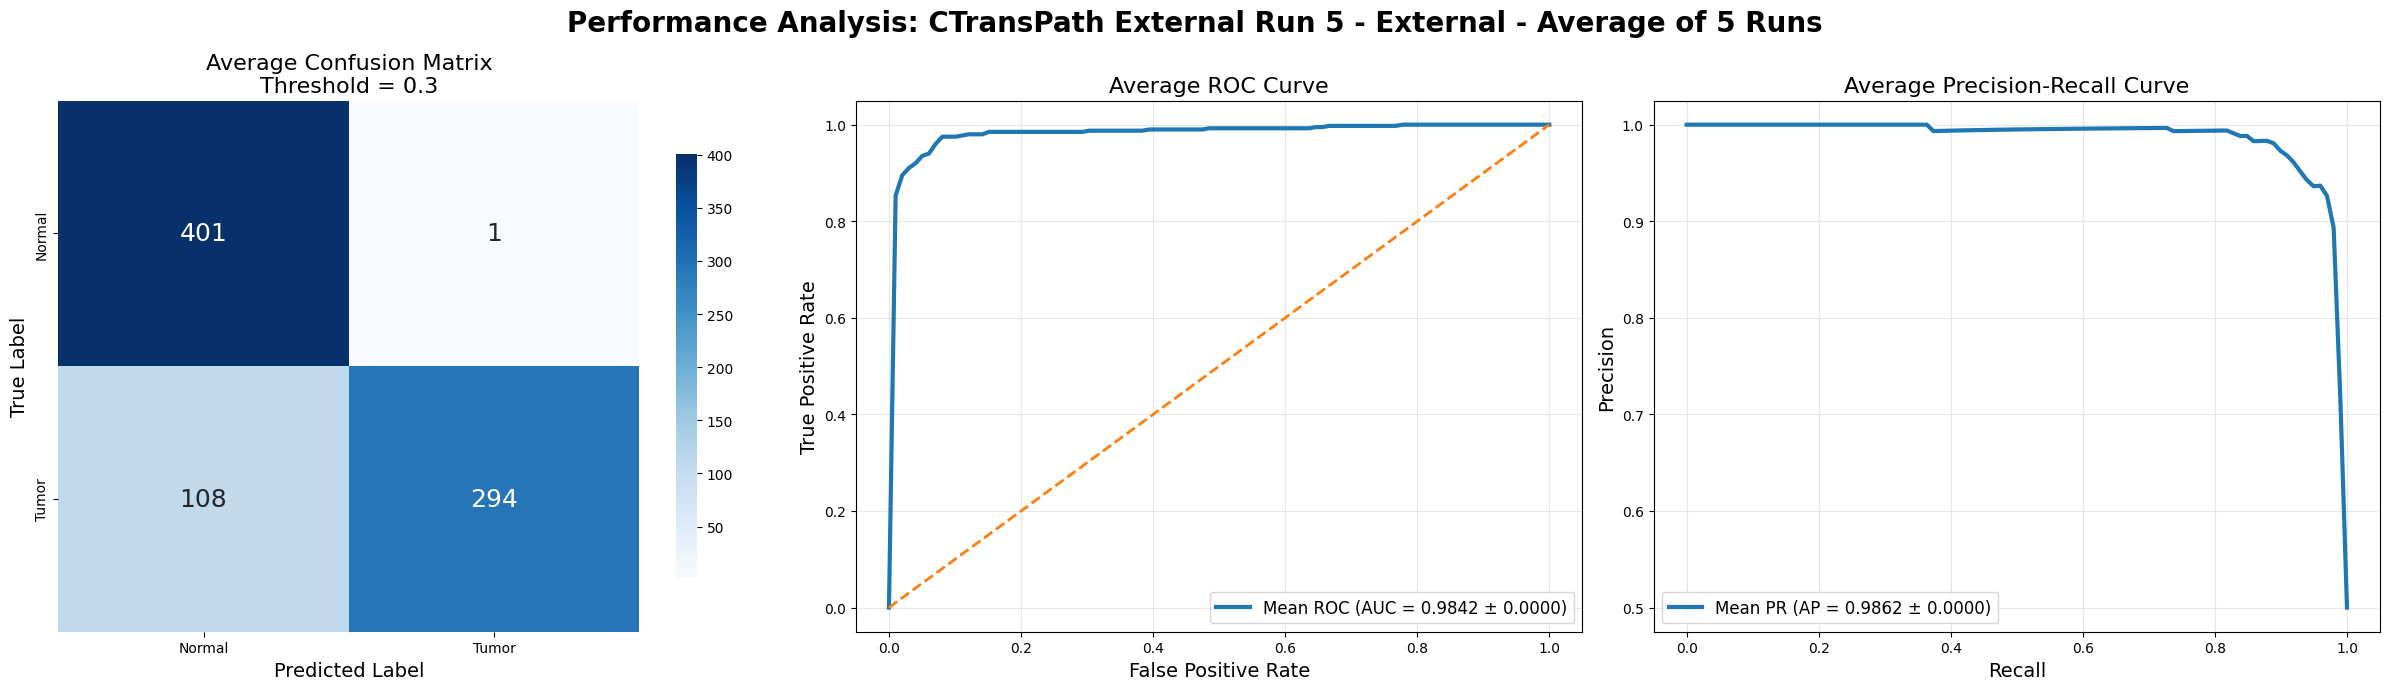


CTRANSPATH EXTERNAL RESULTS
                   extractor  accuracy  precision  specificity    recall  \
0  CTransPath External Run 1  0.931592   0.985994     0.987562  0.875622   
1  CTransPath External Run 2  0.879353   0.993528     0.995025  0.763682   
2  CTransPath External Run 3  0.879353   0.993528     0.995025  0.763682   
3  CTransPath External Run 4  0.776119   0.995536     0.997512  0.554726   
4  CTransPath External Run 5  0.864428   0.996610     0.997512  0.731343   

         f1       auc  run  
0  0.927536  0.991195    1  
1  0.863572  0.987556    2  
2  0.863572  0.987049    3  
3  0.712460  0.938535    4  
4  0.843615  0.984190    5  

CTRANSPATH EXTERNAL FINAL RESULTS (Mean ± Std)
accuracy    : 0.8662 ± 0.0564
precision   : 0.9930 ± 0.0042
specificity : 0.9945 ± 0.0041
recall      : 0.7378 ± 0.1161
f1          : 0.8422 ± 0.0791
auc         : 0.9777 ± 0.0220


In [ ]:
CTRANSPATH_EXTERNAL_DIR = "/content/drive/MyDrive/CPTAC-LUAD_CTransPath_features"

CTRANSPATH_MODEL_PATHS = [
    "/content/best_model_ctranspath_run1.pth",
    "/content/best_model_ctranspath_run2.pth",
    "/content/best_model_ctranspath_run3.pth",
    "/content/best_model_ctranspath_run4.pth",
    "/content/best_model_ctranspath_run5.pth",
]
ctranspath_external_runs = []

for i, model_path in enumerate(CTRANSPATH_MODEL_PATHS, start=1):

    result = external_test_single_extractor(
        extractor_name=f"CTransPath External Run {i}",
        external_test_dir=CTRANSPATH_EXTERNAL_DIR,
        input_dim=768,
        model_path=model_path,
        threshold=0.3
    )

    result["run"] = i
    ctranspath_external_runs.append(result)

ctranspath_external_df = pd.DataFrame(ctranspath_external_runs)

print("\n" + "="*60)
print("CTRANSPATH EXTERNAL RESULTS")
print("="*60)
print(ctranspath_external_df)

print("\n" + "="*60)
print("CTRANSPATH EXTERNAL FINAL RESULTS (Mean ± Std)")
print("="*60)

for metric in ["accuracy", "precision", "specificity", "recall", "f1", "auc"]:
    mean = ctranspath_external_df[metric].mean()
    std = ctranspath_external_df[metric].std()
    print(f"{metric:<12}: {mean:.4f} ± {std:.4f}")